# Healthcare Accessibility in Casablanca: Geospatial Capstone Analysis

## 1. Introduction and Research Question

Access to healthcare is a core dimension of urban equity. In large metropolitan areas such as Casablanca, physical proximity to facilities does not always imply practical access, especially when population concentration, transport infrastructure, and spatial form vary across districts.

This notebook investigates the research question:
**How accessible are healthcare services to the population in Casablanca, and which areas are underserved?**

### Study Objective
- Quantify spatial accessibility to healthcare services across Casablanca.
- Detect geographic disparities between service supply and population demand.
- Identify potentially underserved areas to support evidence-based planning decisions.

### Datasets Used
- Healthcare facilities: point locations of hospitals and clinics.
- Transport stops: bus and tram stops, including mode and route information.
- Administrative boundaries: districts/communes used for aggregation and comparison.
- Population distribution: district-level population attributes and geometries.

### Why This Matters
The analysis supports public health and urban planning by highlighting where residents may face longer travel burdens to reach care. Results can inform priorities for new facilities, improved transit connectivity, and equitable service allocation.

In [71]:
# Defining project paths
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks' and (NOTEBOOK_DIR / 'notebooks').exists():
    REPO_ROOT = NOTEBOOK_DIR
elif NOTEBOOK_DIR.name == 'notebooks' and (NOTEBOOK_DIR.parent / 'data').exists():
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    candidate = next((p for p in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (p / 'data').exists()), NOTEBOOK_DIR)
    REPO_ROOT = candidate

DATA_DIR = REPO_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
ANALYSIS_OUTPUT_DIR = DATA_DIR / 'analysis'
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HEALTHCARE_PATH = PROCESSED_DIR / 'Casablanca_Healthcare.gpkg'
TRANSPORT_PATH = PROCESSED_DIR / 'Casablanca_Transport_Stops.gpkg'
DISTRICTS_PATH = PROCESSED_DIR / 'Casablanca_Districts.gpkg'
POPULATION_PATH = PROCESSED_DIR / 'population_by_districts.gpkg'

CRS_METRIC = 'EPSG:26191'  # Morocco zone 1 (metres)
CRS_GEO = 'EPSG:4326'      # Geographic/web contexts only


In [72]:
import warnings
import ast
from collections import defaultdict

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import seaborn as sns
from folium.plugins import MarkerCluster, HeatMap
from matplotlib.ticker import FuncFormatter
from scipy.spatial import cKDTree
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import folium


def add_north_arrow(ax, x=0.95, y=0.95):
    ax.annotate(
        'N',
        xy=(x, y),
        xytext=(x, y - 0.1),
        xycoords='axes fraction',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        arrowprops=dict(facecolor='black', width=2.0, headwidth=8),
        zorder=10,
    )


def add_web_basemap(ax, gdf_for_crs):
    try:
        ctx.add_basemap(
            ax,
            crs=gdf_for_crs.crs.to_string() if gdf_for_crs.crs else CRS_GEO,
            source=ctx.providers.CartoDB.Positron,
            attribution_size=6,
        )
    except Exception as exc:
        warnings.warn(f'Basemap unavailable: {exc}')


## 2. Data Ingestion

This section loads the four core geospatial layers and confirms row counts and coordinate reference systems (CRS).
A reliable analysis requires consistent schema and geometry metadata before any spatial operation.

In [73]:
# Load files
hospitals = gpd.read_file(HEALTHCARE_PATH)
stops = gpd.read_file(TRANSPORT_PATH)
districts = gpd.read_file(DISTRICTS_PATH)
population = gpd.read_file(POPULATION_PATH)


print(f'Healthcare facilities : {len(hospitals):,} rows | CRS: {hospitals.crs}')
print(f'Transport stops       : {len(stops):,}  rows | CRS: {stops.crs}')
print(f'Districts             : {len(districts):,}  rows | CRS: {districts.crs}')
print(f'Population            : {len(population):,}  rows | CRS: {population.crs}')

Healthcare facilities : 84 rows | CRS: EPSG:4326
Transport stops       : 1,463  rows | CRS: EPSG:4326
Districts             : 34  rows | CRS: EPSG:4326
Population            : 34  rows | CRS: EPSG:4326


## 3. Data Preparation and Standardization

Before analysis, datasets are harmonized to a common spatial reference and key attributes are parsed into analysis-ready formats.
This step is essential to avoid distance distortions and inconsistent joins.

### 3.1 CRS Harmonization and Attribute Parsing

**Why CRS transformation matters:**

Distance and area calculations are only meaningful in a projected coordinate system with meter units.
This notebook uses `EPSG:26191` to standardize spatial operations across layers. This projected CRS is appropriate for metric operations in the Casablanca context and supports more reliable distance-based planning metrics.

**What is done here:**
- Reproject healthcare, transport, district, and population layers to a shared CRS.
- Parse transport `mode` and `Lines` fields from string-like lists into usable Python lists.
- Derive operational features (`primary_mode`, `num_lines`) for later service characterization.


In [74]:
# Reproject to standard metric CRS for all distance/time operations
hospitals = hospitals.to_crs(CRS_METRIC)
stops = stops.to_crs(CRS_METRIC)
districts = districts.to_crs(CRS_METRIC)
population = population.to_crs(CRS_METRIC)


In [75]:
# Robust parsing for list-like columns (mode/lines)
def safe_parse_list(val):
    '''Parse route membership safely from strings/lists/sets/tuples.'''
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return []
    if isinstance(val, (list, tuple, set)):
        seq = list(val)
    else:
        txt = str(val).strip()
        if txt in {'', 'nan', 'None', 'NULL'}:
            return []
        try:
            parsed = ast.literal_eval(txt)
            if isinstance(parsed, (list, tuple, set)):
                seq = list(parsed)
            else:
                seq = [parsed]
        except Exception:
            cleaned = txt.strip('[](){}')
            seq = [part.strip(" '\"") for part in cleaned.replace(';', ',').split(',') if part.strip()]
    result = [str(x).strip() for x in seq if str(x).strip() and str(x).strip().lower() not in {'none', 'nan'}]
    return list(dict.fromkeys(result))


stops['mode_list'] = stops['mode'].apply(safe_parse_list)
stops['lines_list'] = stops['Lines'].apply(safe_parse_list)

stops['primary_mode'] = stops['mode_list'].apply(lambda x: x[0].lower() if x else 'unknown')
stops['num_lines'] = stops['lines_list'].apply(len)

print('Transport modes (raw):')
print(stops['mode'].value_counts())

print('\nPrimary transport modes:')
print(stops['primary_mode'].value_counts())

print(f'\nAvg lines per stop: {stops["num_lines"].mean():.2f}')


Transport modes (raw):
mode
['casabus']              1311
['tram']                   96
['busway']                 41
['tram', 'casabus']         8
['casabus', 'tram']         6
['busway', 'casabus']       1
Name: count, dtype: int64

Primary transport modes:
primary_mode
casabus    1317
tram        104
busway       42
Name: count, dtype: int64

Avg lines per stop: 1.97


In [76]:
# Create district centroids for origin points
districts['centroid'] = districts.geometry.centroid
districts['centroid_x'] = districts.centroid.x
districts['centroid_y'] = districts.centroid.y

# Calculate district area in km²
districts['area_km2'] = districts.geometry.area / 1_000_000

print("✓ District centroids created")
print(f"Total study area: {districts['area_km2'].sum():.2f} km²")

✓ District centroids created
Total study area: 837.37 km²


## 4. Exploratory Data Analysis (EDA)

The EDA phase establishes baseline patterns in service distribution and demographic concentration.
Each visualization is interpreted in terms of urban structure, centrality, and potential inequality in healthcare access.

In [77]:
# Quick peek at each dataset
print('=== HEALTHCARE ===')
display(hospitals.head(2))
print('\n=== TRANSPORT STOPS ===')
display(stops.head(2))
print('\n=== DISTRICTS ===')
display(districts.head(2))
print('\n=== POPULATION ===')
display(population.head(2))

=== HEALTHCARE ===


,name,latitude,longitude,geometry
0,clinique badr,33.594870,-7.641098,POINT (291920.324 335215.916)
1,hôpital sidi othmane,33.558542,-7.573301,POINT (298125.831 331055.95)



=== TRANSPORT STOPS ===


,cluster_id,stop_name,Lines,mode,longitude,latitude,geometry,mode_list,lines_list,primary_mode,num_lines
0,0,112 Boulevard D'Anfa,"['L09E', 'L084', 'L050', 'L013']",['casabus'],-7.633955,33.592059,POINT (292576.333 334890.127),[casabus],"[L09E, L084, L050, L013]",casabus,4
1,1,112 Boulevard D'Anfa,"['L09E', 'L084', 'L050', 'L013']",['casabus'],-7.633524,33.592137,POINT (292616.456 334897.919),[casabus],"[L09E, L084, L050, L013]",casabus,4



=== DISTRICTS ===


,district,commune,commune_type_encoded,geometry,centroid,centroid_x,centroid_y,area_km2
0,Bouskoura,Bouskoura,0,"MULTIPOLYGON (((287134.376 315119.858, 287122....",POINT (291645.27 320753.949),291645.269669,320753.949134,114.642679
1,Bouskoura,Dar Bouazza,0,"MULTIPOLYGON (((279913.516 320395.141, 279205....",POINT (279290.48 325706.334),279290.479797,325706.334394,150.362928



=== POPULATION ===


,commune,population,geometry
0,tit mellil,56019,"MULTIPOLYGON (((305855.048 327227.132, 304990...."
1,mediouna,29972,"MULTIPOLYGON (((302503.339 319077.372, 302558...."


In [78]:
# Data types and null counts
print('--- Healthcare info ---')
hospitals.info()
print('\n--- Stops info ---')
stops.info()
print('\n--- Districts info ---')
districts.info()
print('\n--- Population info ---')
population.info()

--- Healthcare info ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   name       84 non-null     object  
 1   latitude   84 non-null     float64 
 2   longitude  84 non-null     float64 
 3   geometry   84 non-null     geometry
dtypes: float64(2), geometry(1), object(1)
memory usage: 2.8+ KB

--- Stops info ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1463 entries, 0 to 1462
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cluster_id    1463 non-null   int64   
 1   stop_name     1463 non-null   object  
 2   Lines         1463 non-null   object  
 3   mode          1463 non-null   object  
 4   longitude     1463 non-null   float64 
 5   latitude      1463 non-null   float64 
 6   geometry      1463 non-null   geometry
 7   mode_list     1463 

### 4.1 Spatial Validation and Coverage Diagnostics

Before interpreting access, we verify that layers occupy the same geographic extent and that point patterns align with district boundaries.


In [79]:
# ── Geographic extent / bounding box comparison ──────────────────────────
print('Healthcare bounding box:')
print(f'  Lat: {hospitals.latitude.min():.4f} → {hospitals.latitude.max():.4f}')
print(f'  Lon: {hospitals.longitude.min():.4f} → {hospitals.longitude.max():.4f}')

print('\nTransport bounding box:')
print(f'  Lat: {stops.latitude.min():.4f} → {stops.latitude.max():.4f}')
print(f'  Lon: {stops.longitude.min():.4f} → {stops.longitude.max():.4f}')

Healthcare bounding box:
  Lat: 33.4942 → 33.6401
  Lon: -7.7327 → -7.4488

Transport bounding box:
  Lat: 33.3717 → 33.7088
  Lon: -7.8853 → -7.3305


Comparable bounding extents indicate that healthcare and transport datasets likely describe the same urban system.

#### Distribution of healthcare facilities and transport stops

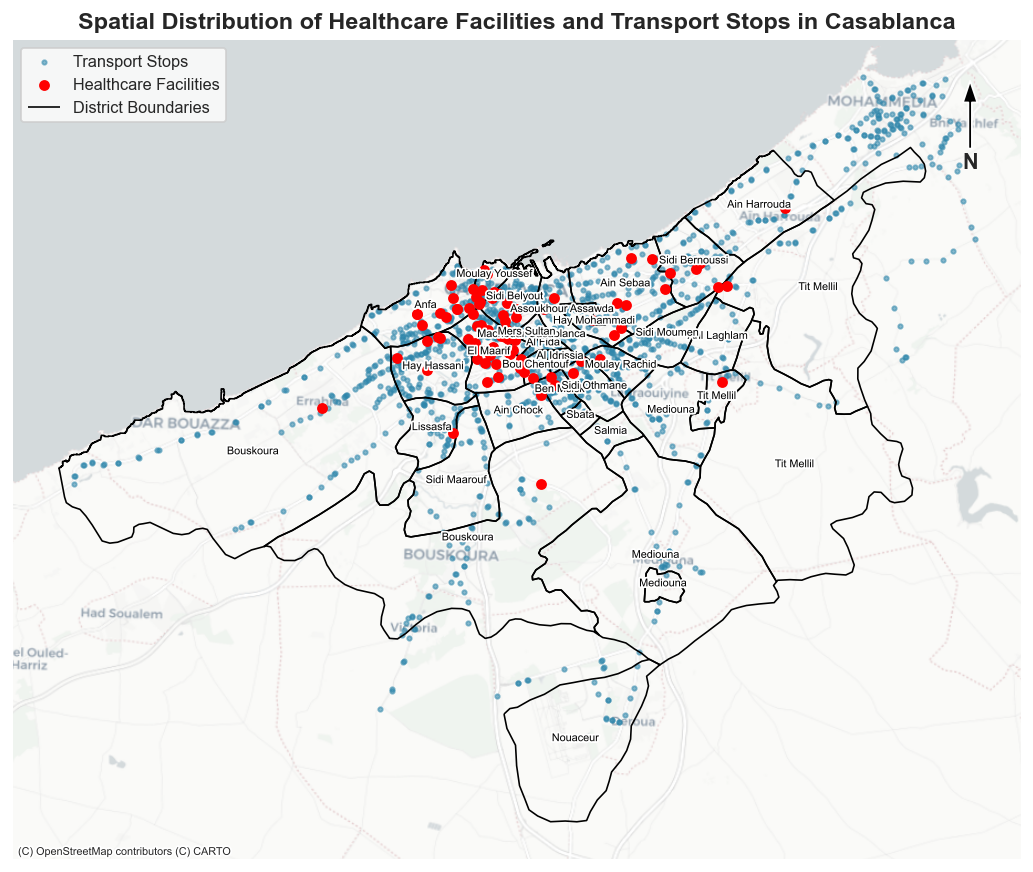

In [80]:
fig, ax = plt.subplots(figsize=(10, 10))

stops.plot(ax=ax, markersize=6, alpha=0.55, label='Transport Stops', color='#2E86AB')
hospitals.plot(ax=ax, color='red', markersize=25, label='Healthcare Facilities', zorder=5)
districts.boundary.plot(ax=ax, color='black', linewidth=0.9, label='District Boundaries', zorder=4)

name_col = 'district' if 'district' in districts.columns else 'commune'
for _, row in districts.iterrows():
    ax.annotate(
        str(row[name_col]),
        xy=(row['centroid'].x, row['centroid'].y),
        fontsize=6,
        ha='center',
        color='black',
        path_effects=[pe.withStroke(linewidth=2, foreground='white')],
        zorder=6,
    )

add_web_basemap(ax, districts)
add_north_arrow(ax)
plt.legend()
plt.title('Spatial Distribution of Healthcare Facilities and Transport Stops in Casablanca')
plt.axis('off')
plt.savefig(ANALYSIS_OUTPUT_DIR / 'SpatialVisualization.png', bbox_inches='tight')
plt.show()


This map provides a first visual test of service geography. Healthcare points are concentrated in central districts while peripheral areas show sparse facility coverage.

### Transport mode distribution

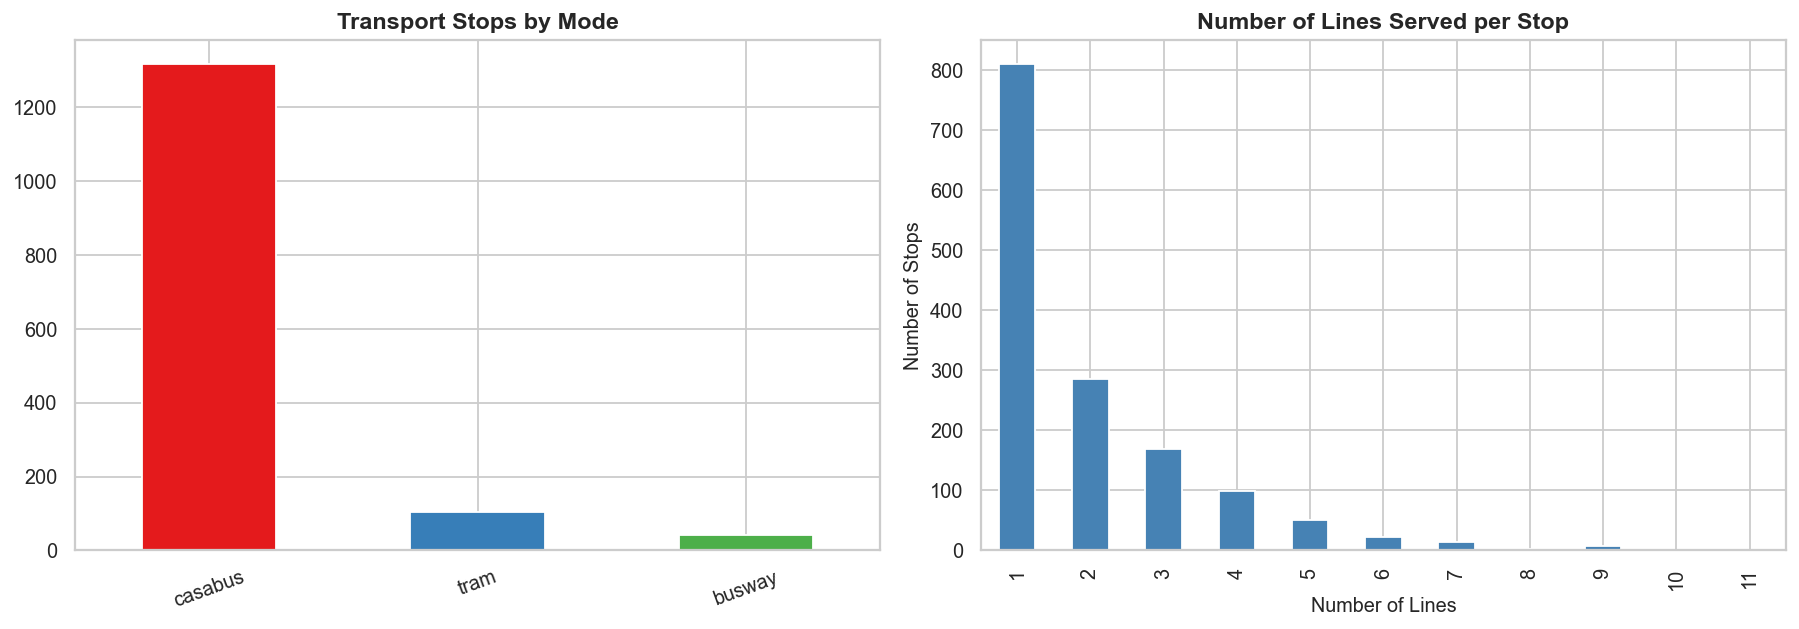


Summary:
  Stops with only 1 line : 810 (55.4%)
  Stops with 3+ lines    : 368 (25.2%)


In [81]:
# ── Transport mode distribution & lines per stop ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mode counts
mode_counts = stops['primary_mode'].value_counts()
mode_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set1'), edgecolor='white')
axes[0].set_title('Transport Stops by Mode', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Lines per stop
stops['num_lines'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Number of Lines Served per Stop', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Lines')
axes[1].set_ylabel('Number of Stops')

plt.tight_layout()
plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/transport_eda.png', bbox_inches='tight')
plt.show()

print(f'\nSummary:')
print(f'  Stops with only 1 line : {(stops["num_lines"]==1).sum()} ({(stops["num_lines"]==1).mean()*100:.1f}%)')
print(f'  Stops with 3+ lines    : {(stops["num_lines"]>=3).sum()} ({(stops["num_lines"]>=3).mean()*100:.1f}%)')

The results indicate a clear spatial imbalance in transport provision across Casablanca. The network is strongly bus-dominant relative to tram, so rail-based accessibility is structurally limited to fewer corridors.


# Population Density per District

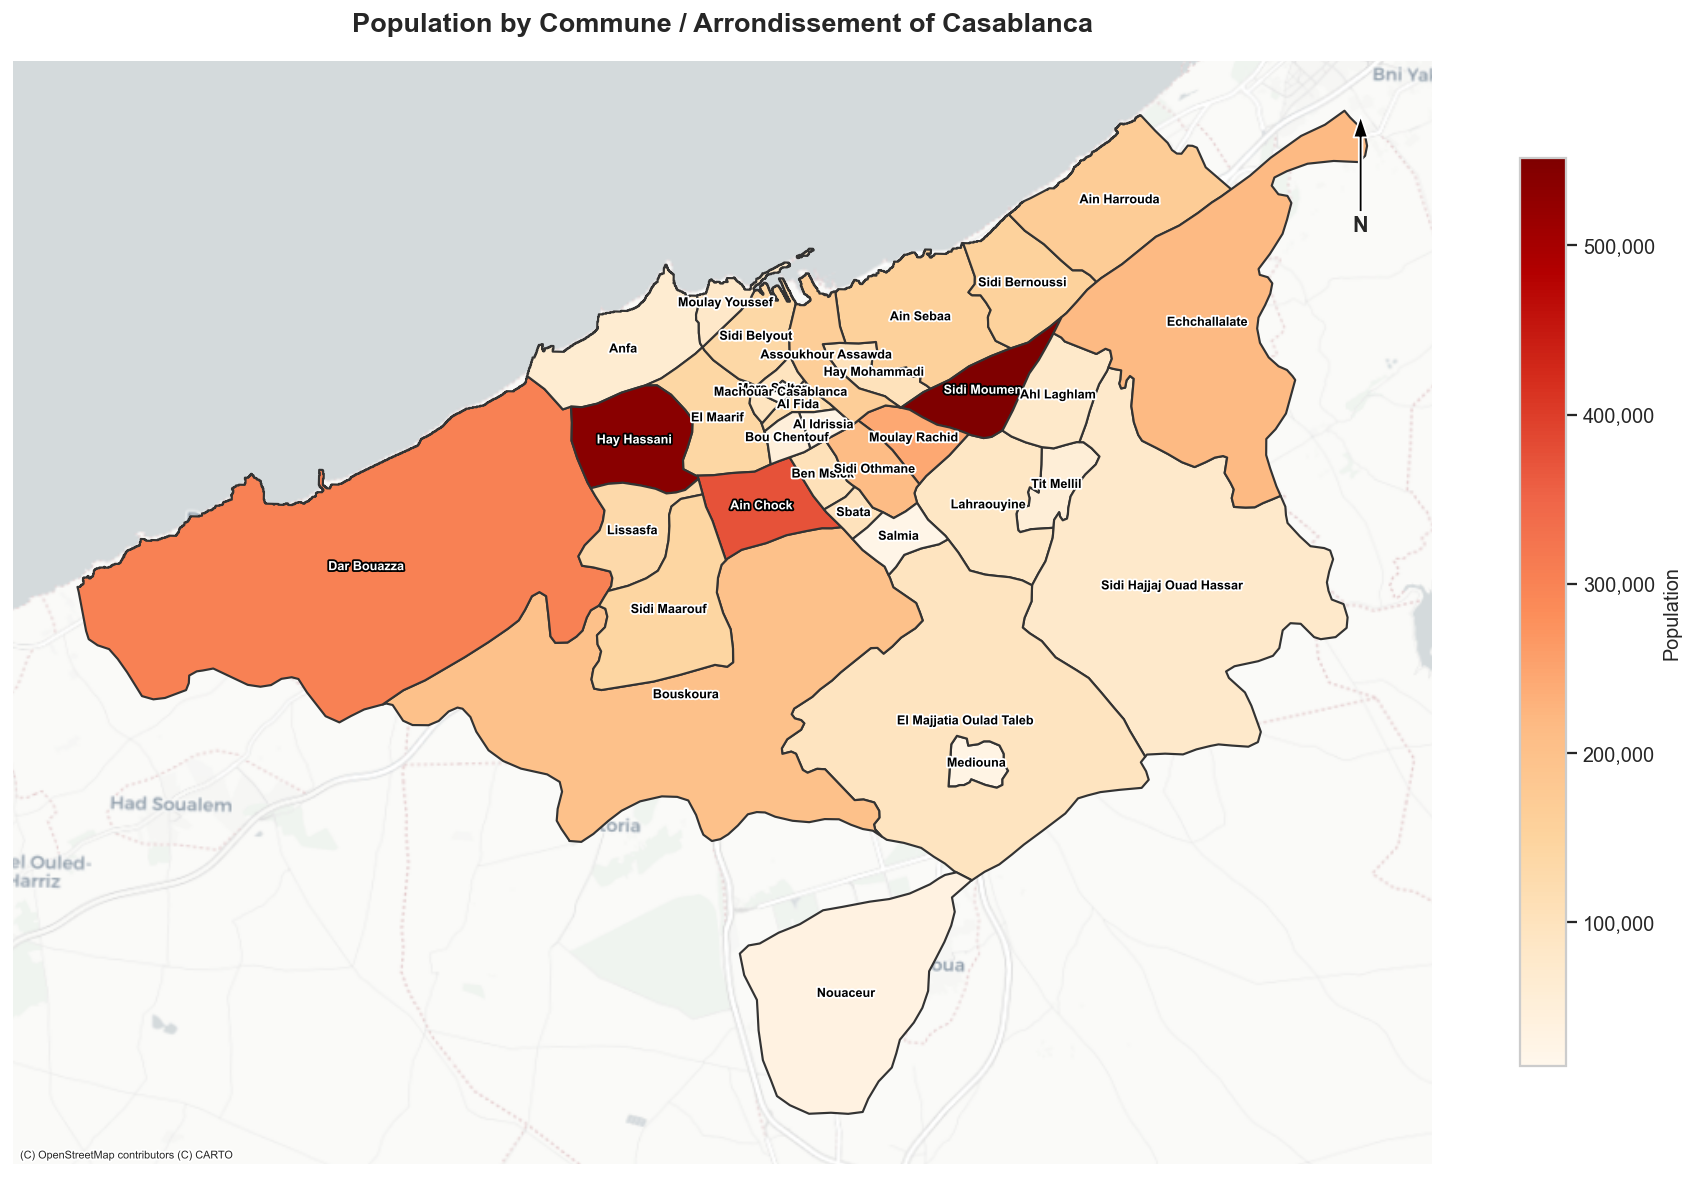

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

population.plot(
    column='population',
    cmap='OrRd',
    linewidth=1.2,
    edgecolor='#333333',
    legend=True,
    legend_kwds={
        'label': 'Population',
        'orientation': 'vertical',
        'shrink': 0.6,
        'format': FuncFormatter(lambda x, _: f'{int(x):,}'),
    },
    ax=ax,
)

for _, row in population.iterrows():
    pop = row['population']
    name = row['commune'].title() if 'commune' in row else row.get('district', 'N/A')
    text_color = 'white' if pop > 300_000 else 'black'
    ax.annotate(
        name,
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center',
        va='center',
        fontsize=7,
        color=text_color,
        fontweight='bold',
        path_effects=[pe.withStroke(linewidth=2, foreground='white' if text_color == 'black' else 'black')],
    )

add_web_basemap(ax, population)
add_north_arrow(ax)
ax.set_title('Population by Commune / Arrondissement of Casablanca', fontsize=15, fontweight='bold', pad=16)
ax.axis('off')

plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'population_by_districts.png', dpi=300, bbox_inches='tight')
plt.show()


The population choropleth highlights where demand pressure is likely to be highest.

Areas with high density but limited nearby healthcare or weak transit connectivity are likely to experience disproportionate access burdens.

# Healthcare facilities per district

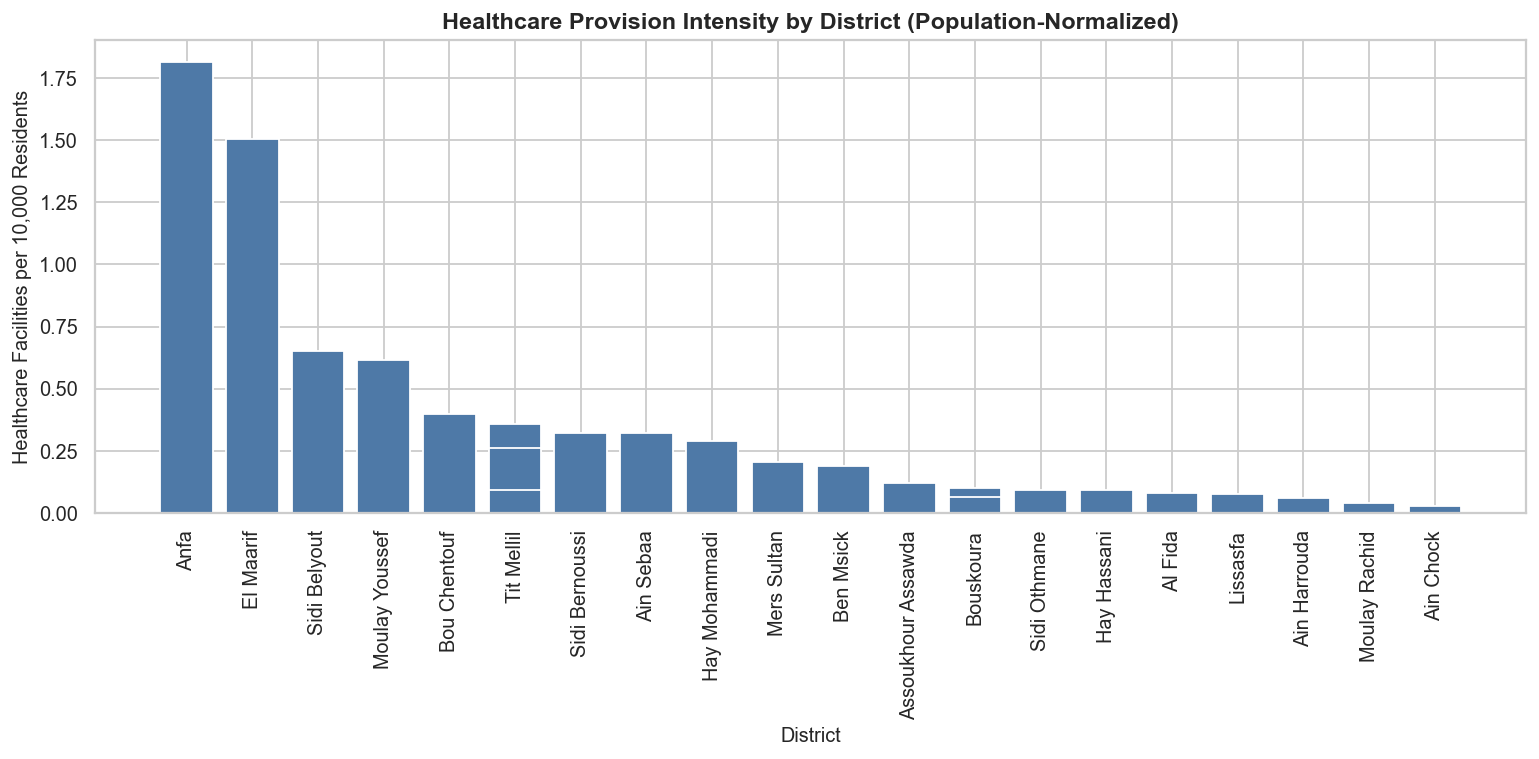

In [83]:
# Join healthcare facilities with districts and normalize by population
healthcare_with_districts = gpd.sjoin(hospitals, districts, how='left', predicate='within')
districts_with_population = gpd.sjoin(districts, population, how='left', predicate='within')

district_name_col = 'district' if 'district' in districts_with_population.columns else 'commune'

healthcare_counts = (
    healthcare_with_districts.groupby(district_name_col)
    .size()
    .reset_index(name='num_healthcare')
)

metrics = districts_with_population[[district_name_col, 'population']].drop_duplicates()
healthcare_counts = healthcare_counts.merge(metrics, on=district_name_col, how='left')
healthcare_counts['facilities_per_10k'] = (
    10_000 * healthcare_counts['num_healthcare'] / healthcare_counts['population'].replace(0, np.nan)
)
healthcare_counts = healthcare_counts.sort_values(by='facilities_per_10k', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(healthcare_counts[district_name_col], healthcare_counts['facilities_per_10k'], color='#4E79A7')
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Healthcare Facilities per 10,000 Residents')
plt.title('Healthcare Provision Intensity by District (Population-Normalized)')
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'healthcare_per_10000_residents.png', dpi=300, bbox_inches='tight')
plt.show()


Healthcare facilities are unevenly distributed across districts.
A small number of central districts account for a disproportionately large share of facilities, while many districts have low observed supply.

# Transport Stops Per District

To explore the spatial distribution of public transport infrastructure, we computed the total number of stops (including both bus and tramway) within each district.

Each stop was assigned to a district using a spatial join, and counts were aggregated to identify areas with higher concentrations of transport services. The results are visualized in the bar chart below.

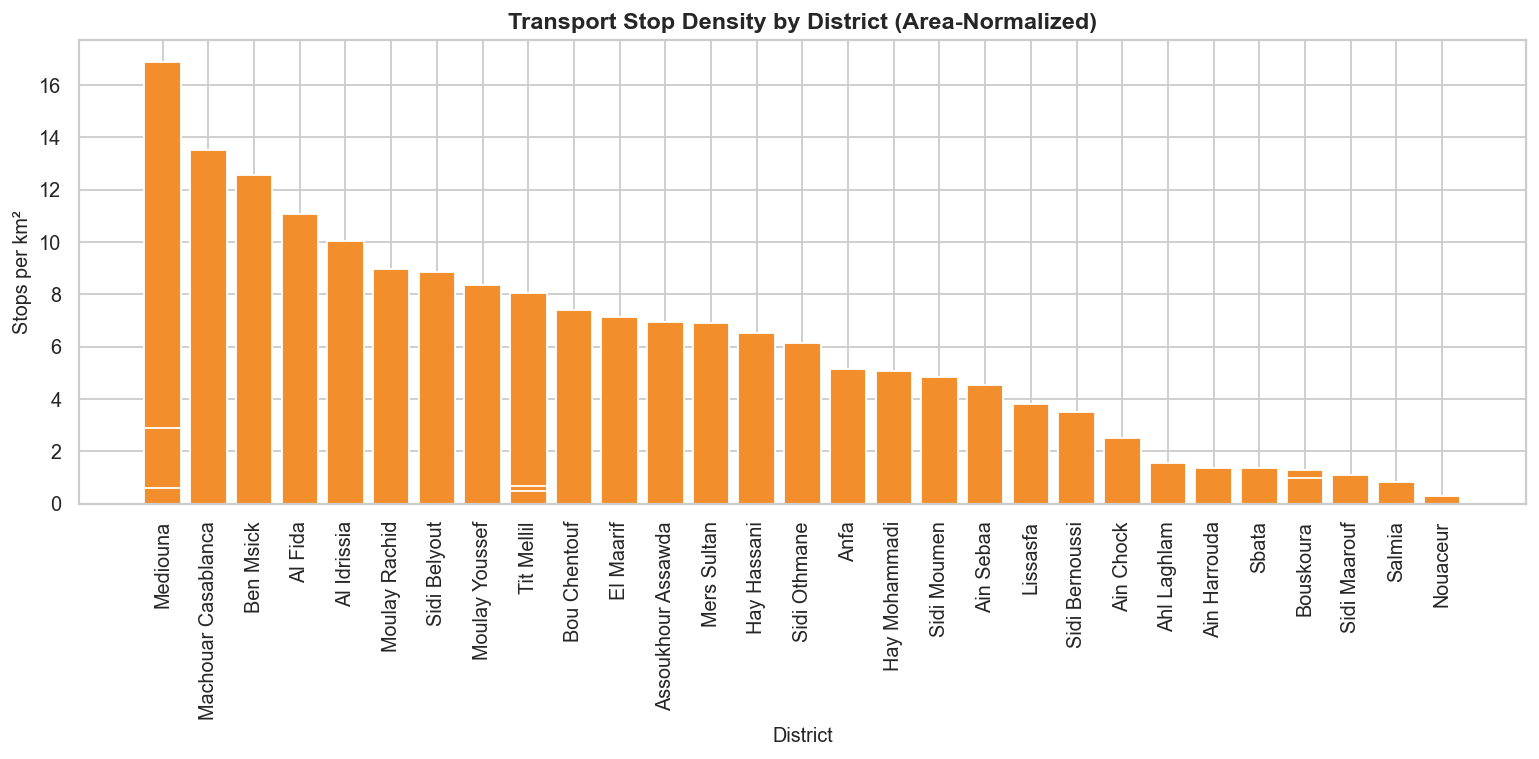

In [84]:
# Spatial join to assign each stop to a district
stops_with_districts = gpd.sjoin(stops, districts, how='left', predicate='within')
district_name_col = 'district' if 'district' in districts.columns else 'commune'

stops_count = stops_with_districts.groupby(district_name_col).size().reset_index(name='num_stops')
area_lookup = districts[[district_name_col, 'area_km2']].drop_duplicates()
stops_count = stops_count.merge(area_lookup, on=district_name_col, how='left')
stops_count['stops_per_km2'] = stops_count['num_stops'] / stops_count['area_km2'].replace(0, np.nan)
stops_count = stops_count.sort_values(by='stops_per_km2', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(stops_count[district_name_col], stops_count['stops_per_km2'], color='#F28E2B')
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Stops per km²')
plt.title('Transport Stop Density by District (Area-Normalized)')
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'stops_per_km2.png', dpi=300, bbox_inches='tight')
plt.show()


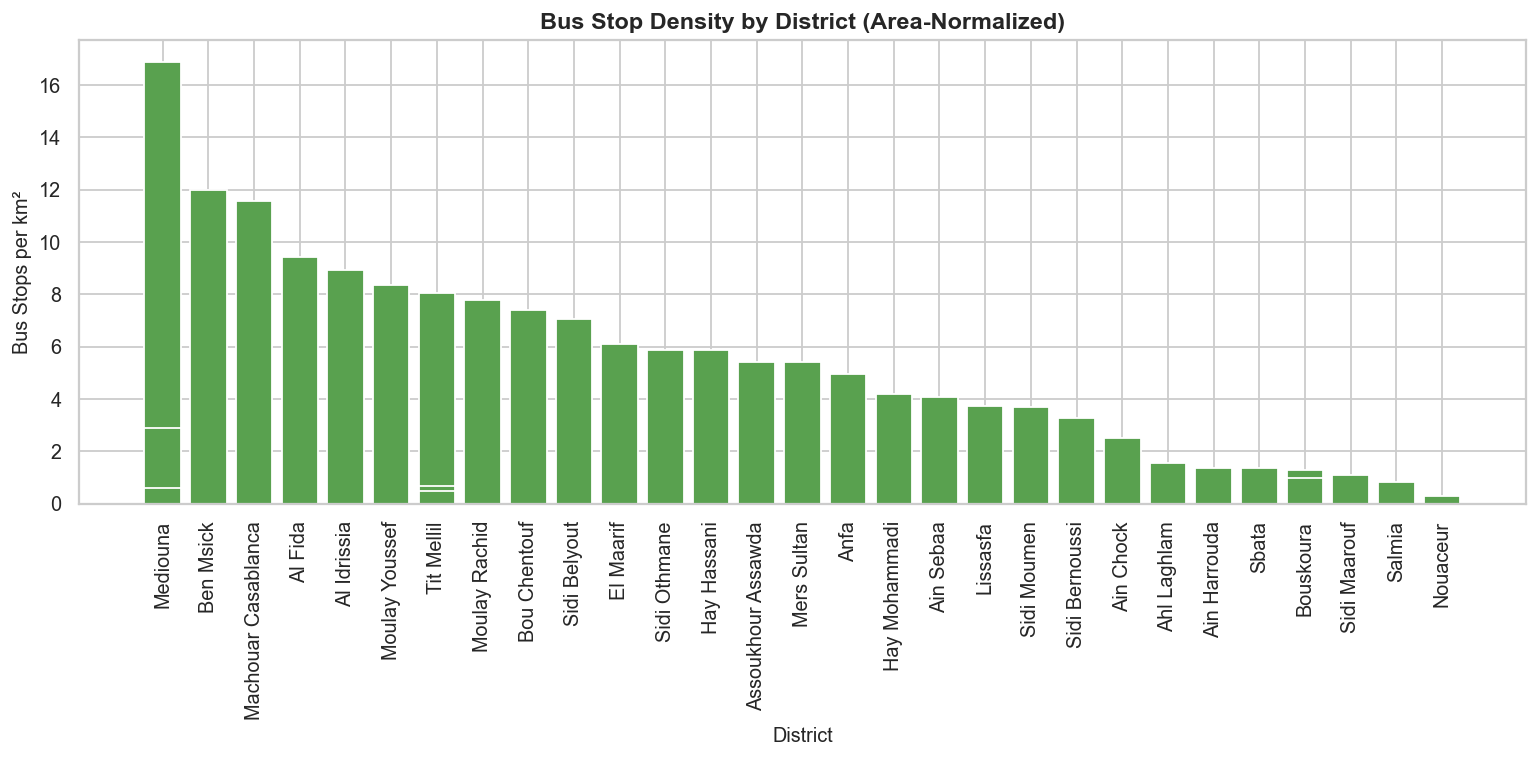

In [85]:
bus_stops = stops_with_districts[stops_with_districts['primary_mode'].isin(['casabus', 'busway'])]

bus_counts = (
    bus_stops.groupby(district_name_col)
    .size()
    .reset_index(name='num_bus_stops')
    .merge(area_lookup, on=district_name_col, how='left')
)
bus_counts['bus_stops_per_km2'] = bus_counts['num_bus_stops'] / bus_counts['area_km2'].replace(0, np.nan)
bus_counts = bus_counts.sort_values(by='bus_stops_per_km2', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(bus_counts[district_name_col], bus_counts['bus_stops_per_km2'], color='#59A14F')
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Bus Stops per km²')
plt.title('Bus Stop Density by District (Area-Normalized)')
plt.tight_layout()
plt.show()


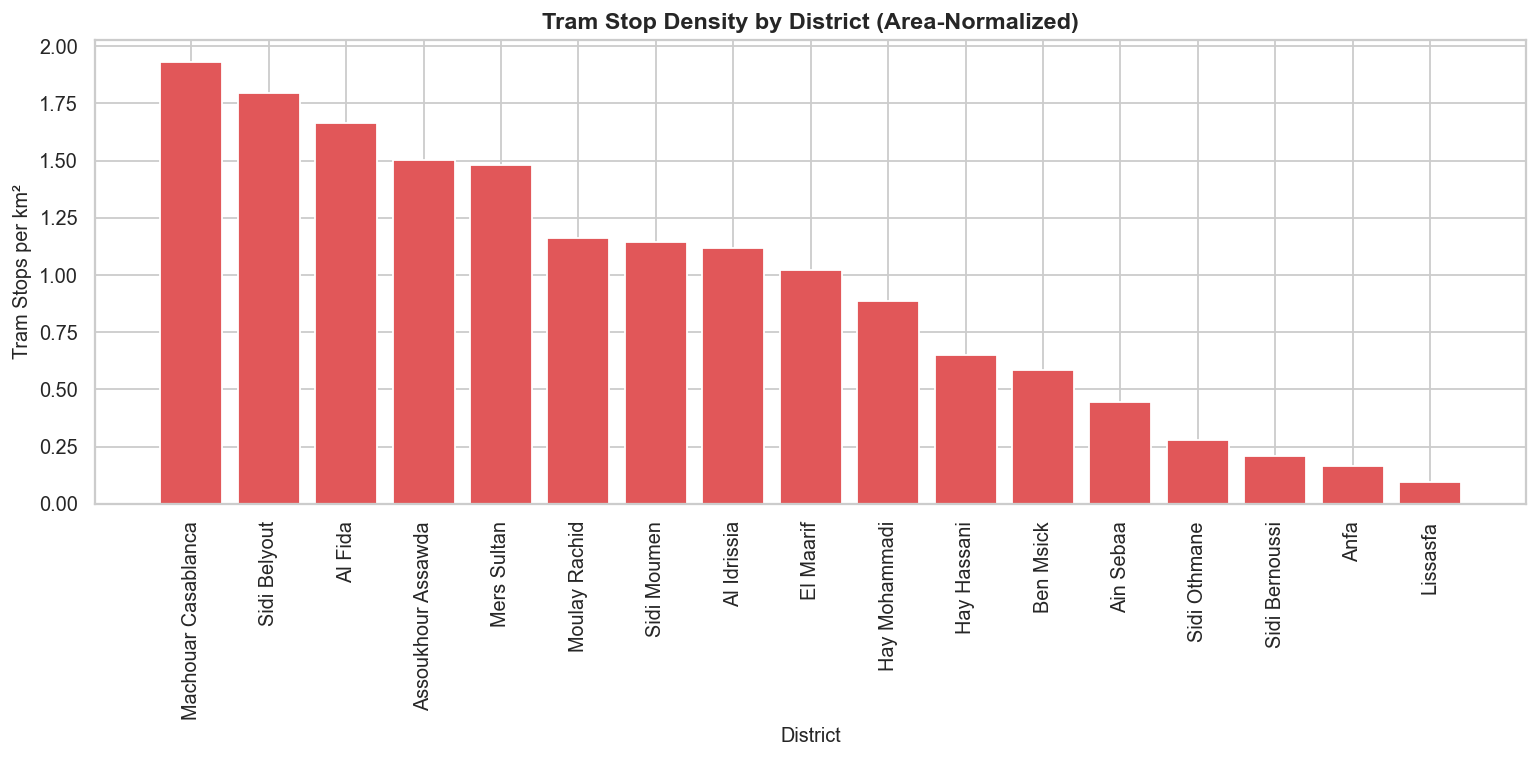

In [86]:
tram_stops = stops_with_districts[stops_with_districts['primary_mode'] == 'tram']

tram_counts = (
    tram_stops.groupby(district_name_col)
    .size()
    .reset_index(name='num_tram_stops')
    .merge(area_lookup, on=district_name_col, how='left')
)
tram_counts['tram_stops_per_km2'] = tram_counts['num_tram_stops'] / tram_counts['area_km2'].replace(0, np.nan)
tram_counts = tram_counts.sort_values(by='tram_stops_per_km2', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(tram_counts[district_name_col], tram_counts['tram_stops_per_km2'], color='#E15759')
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Tram Stops per km²')
plt.title('Tram Stop Density by District (Area-Normalized)')
plt.tight_layout()
plt.show()


District-level results show a strong concentration of stops in selected zones, with much weaker presence elsewhere.

By mode:
- Bus and busway stops drive most of the observed coverage.
- Tram stops are fewer and spatially concentrated, creating corridor-specific accessibility advantages.

This asymmetry matters because equitable healthcare access depends not only on facility placement but also on the distribution and diversity of transit connections.

# Population density and healthcare facilities distribution

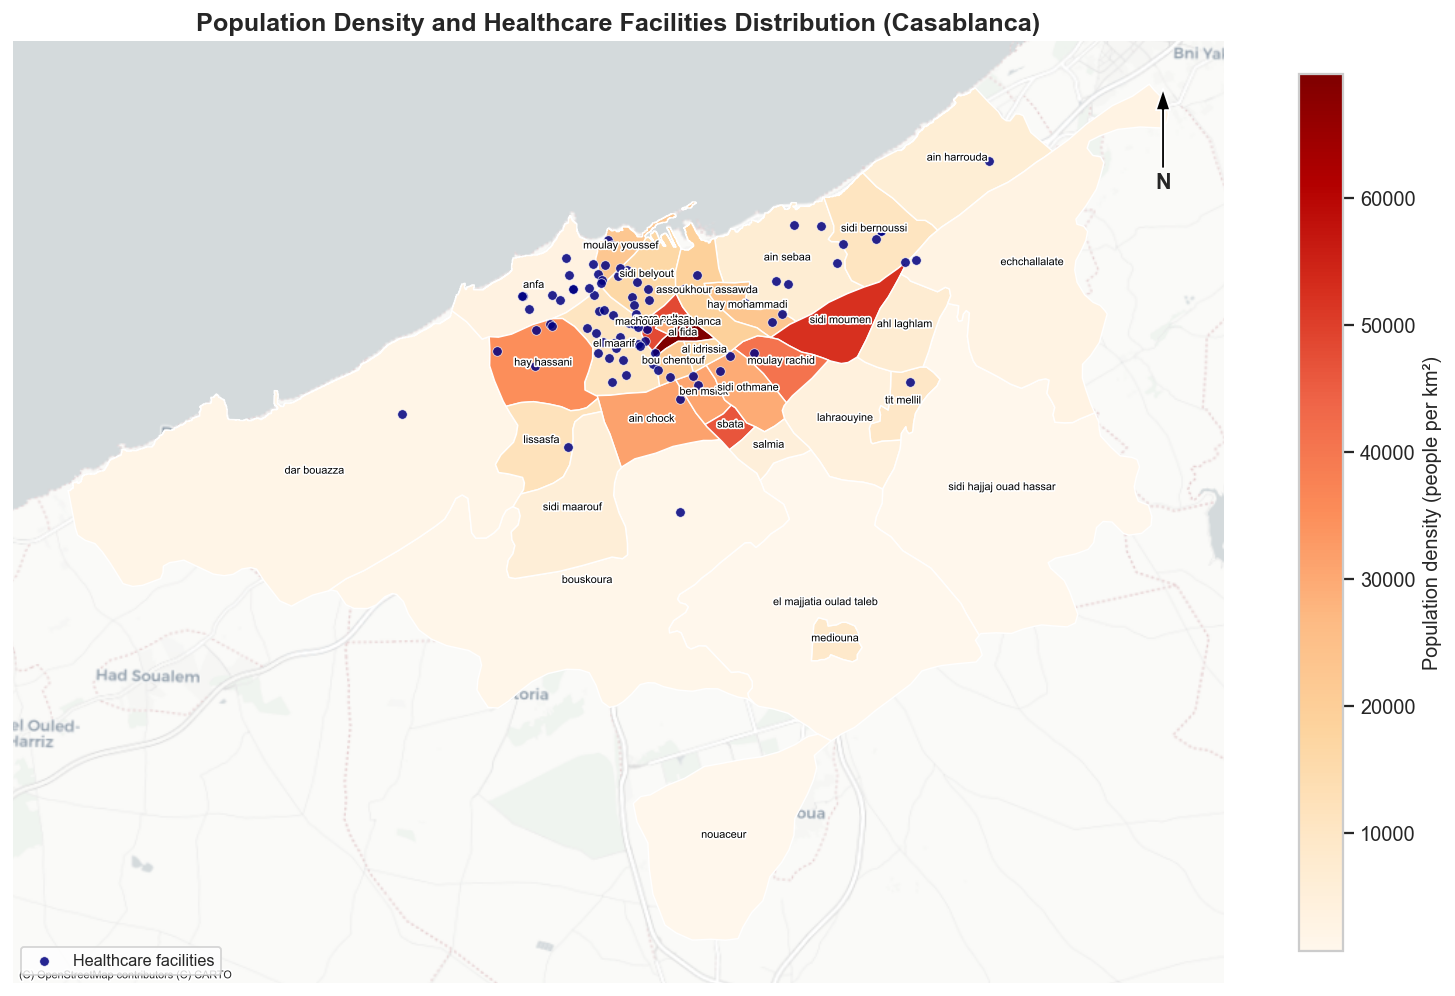

In [87]:
# Population density map + healthcare facilities overlay
pop_map = population.to_crs(CRS_METRIC)
pop_map['area_km2'] = pop_map.geometry.area / 1e6
pop_map['pop_density_km2'] = pop_map['population'] / pop_map['area_km2']

fig, ax = plt.subplots(figsize=(12, 10))

pop_map.plot(
    column='pop_density_km2',
    cmap='OrRd',
    linewidth=0.8,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Population density (people per km²)', 'shrink': 0.7},
    ax=ax,
)

hospitals.plot(
    ax=ax,
    color='navy',
    markersize=28,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.4,
    label='Healthcare facilities',
)

name_col = 'district' if 'district' in pop_map.columns else 'commune'
for _, row in pop_map.iterrows():
    ax.annotate(
        str(row[name_col]),
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=6,
        ha='center',
        color='black',
        path_effects=[pe.withStroke(linewidth=1.8, foreground='white')],
    )

add_web_basemap(ax, pop_map)
add_north_arrow(ax)
ax.set_title('Population Density and Healthcare Facilities Distribution (Casablanca)', fontsize=14, fontweight='bold')
ax.axis('off')
ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'population_density_healthcare_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


The overlay suggests a **mismatch between demand and service location** in Casablanca.

- Healthcare facilities appear concentrated in a limited set of central districts (notably **El Maarif**, **Anfa**, and **Sidi Belyout**).
- Several districts with large populations (e.g., **Sidi Moumen**, **Hay Hassani**, **Ain Chock**) show comparatively fewer facilities relative to their population size.
- Peripheral communes with lower density generally have sparse healthcare coverage, which may increase travel burdens.

Overall, the pattern indicates potential **spatial inequity** in healthcare access: areas with higher population pressure do not always coincide with higher facility availability.  

# 5. Methodology for Accessibility Assessment

This section operationalizes accessibility as a measurable spatial concept and links methods to the research question.

## 5.0 Methodological Scope, Assumptions, and Limitations

### Accessibility Definition Used in This Notebook
Accessibility is treated as the relative ease with which residents can reach healthcare services, approximated through spatial proximity and time-based indicators.

### Core Assumptions
- Spatial proximity is a meaningful first-order proxy for service access.
- Average speeds and waiting times represent typical urban travel conditions.
- District-level aggregation is appropriate for strategic planning insights.

### Limitations
- Straight-line or simplified network distances may differ from real route-constrained travel.
- Temporal effects (peak congestion, schedule reliability) are not fully modeled.
- Service quality and capacity differences across healthcare facilities are not explicitly weighted.

### DBSCAN in Underserved-Area Detection
Where clustering is applied, DBSCAN helps detect dense and sparse spatial patterns without predefining the number of clusters.
In this project context, sparse or low-density clusters can be interpreted as candidate underserved zones requiring closer planning attention.

# 6. Time-Based Accessibility Framework

### 6.1 Conceptual Model

The notebook extends pure distance metrics into a time-based model combining walking, waiting, and in-network movement.
This is more policy-relevant than fixed-radius methods because it better reflects real travel burdens experienced by residents.

### Fixed-Radius vs Distance/Time-Based Approaches
- Fixed-radius approaches are simple and interpretable but assume equal mobility and uniform network quality.
- Distance/time-based approaches capture heterogeneity in transport structure and are better suited for equity diagnostics in large cities like Casablanca.

In [88]:
# Constants for time calculations
WALKING_SPEED = 3.6        # km/h (average walking speed)
BUS_SPEED = 20           # km/h (average bus speed in urban areas)
WAIT_TIME = 10           # minutes (average waiting time for bus)
TRANSFER_TIME = 5        # minutes (time penalty for transfers)
ACCESSIBILITY_MAX_TIME = 45  # minutes; set to 30 for stricter policy ceiling

WALKING_SPEED_M_MIN = (WALKING_SPEED * 1000) / 60
BUS_SPEED_M_MIN = (BUS_SPEED * 1000) / 60

print(f'Walking speed: {WALKING_SPEED} km/h ({WALKING_SPEED_M_MIN:.1f} m/min)')
print(f'Bus speed: {BUS_SPEED} km/h ({BUS_SPEED_M_MIN:.1f} m/min)')
print(f'Average wait time: {WAIT_TIME} minutes')
print(f'Transfer penalty: {TRANSFER_TIME} minutes')
print(f'Accessibility score ceiling: {ACCESSIBILITY_MAX_TIME} minutes')


Walking speed: 3.6 km/h (60.0 m/min)
Bus speed: 20 km/h (333.3 m/min)
Average wait time: 10 minutes
Transfer penalty: 5 minutes
Accessibility score ceiling: 45 minutes


In [89]:
def calculate_nearest_distances(origins_gdf, destinations_gdf, k=1):
    """
    Calculate distances from origins to k nearest destinations using spatial index.
    
    Parameters:
    -----------
    origins_gdf : GeoDataFrame
        Origin points (e.g., district centroids)
    destinations_gdf : GeoDataFrame
        Destination points (e.g., healthcare facilities, transport stops)
    k : int
        Number of nearest destinations to find
    
    Returns:
    --------
    distances : array
        Distances in meters to k nearest destinations
    indices : array
        Indices of k nearest destinations
    """
    # Extract coordinates
    origin_coords = np.array([(geom.x, geom.y) for geom in origins_gdf.geometry])
    dest_coords = np.array([(geom.x, geom.y) for geom in destinations_gdf.geometry])
    
    # Build spatial index
    tree = cKDTree(dest_coords)
    
    # Query k nearest neighbors
    distances, indices = tree.query(origin_coords, k=k)
    
    return distances, indices

In [90]:
# Calculate distance from district centroids to nearest transport stop
print("Calculating walking distances to nearest transport stops...")

# Use centroids as origin points
origin_points = gpd.GeoDataFrame(
    districts.drop('geometry', axis=1).copy(),
    geometry=districts['centroid'],
    crs=districts.crs
)

# Find nearest transport stop
distances_to_stop, stop_indices = calculate_nearest_distances(
    origin_points, stops, k=1
)

# Calculate walking time in minutes
districts['walk_dist_to_stop_m'] = distances_to_stop
districts['walk_time_to_stop_min'] = distances_to_stop / WALKING_SPEED_M_MIN

print(f"✓ Walking distances calculated")
print(f"\nWalking time to nearest stop statistics:")
print(districts['walk_time_to_stop_min'].describe())
print(f"\nDistricts with >15 min walk: {(districts['walk_time_to_stop_min'] > 15).sum()}")

Calculating walking distances to nearest transport stops...
✓ Walking distances calculated

Walking time to nearest stop statistics:
count    34.000000
mean     10.019147
std      14.769323
min       0.787217
25%       2.879263
50%       4.406798
75%       8.308702
max      64.209571
Name: walk_time_to_stop_min, dtype: float64

Districts with >15 min walk: 5


### 5.2 Calculate Travel Time from Transport Stops to Healthcare Facilities

In [91]:
# Build line-aware transport network graph
print('Building transport network graph...')

G = nx.Graph()
for idx, row in stops.iterrows():
    G.add_node(
        f'stop_{idx}',
        pos=(row.geometry.x, row.geometry.y),
        node_type='stop',
        stop_index=idx,
        lines=set(row.get('lines_list', [])),
    )

for idx, row in hospitals.iterrows():
    G.add_node(f'health_{idx}', pos=(row.geometry.x, row.geometry.y), node_type='health', health_index=idx)

seq_candidates = [
    c for c in ['sequence', 'seq', 'stop_sequence', 'route_seq', 'line_sequence', 'order'] if c in stops.columns
]
line_to_stop_records = defaultdict(list)

for idx, row in stops.iterrows():
    for line in row.get('lines_list', []):
        if not line:
            continue
        seq_val = np.nan
        for c in seq_candidates:
            raw_val = row.get(c, np.nan)
            if isinstance(raw_val, str) and raw_val.strip().startswith('{'):
                try:
                    raw_val = ast.literal_eval(raw_val).get(line, np.nan)
                except Exception:
                    raw_val = np.nan
            if pd.notna(raw_val):
                seq_val = raw_val
                break
        line_to_stop_records[line].append((idx, row.geometry.x, row.geometry.y, seq_val))

for line_name, recs in line_to_stop_records.items():
    if len(recs) < 2:
        continue

    has_sequence = any(pd.notna(rec[3]) for rec in recs)
    if has_sequence:
        recs_sorted = sorted(recs, key=lambda x: (pd.isna(x[3]), float(x[3]) if pd.notna(x[3]) else np.inf))
        candidate_pairs = list(zip(recs_sorted[:-1], recs_sorted[1:]))
    else:
        candidate_pairs = []
        for i in range(len(recs)):
            for j in range(i + 1, len(recs)):
                candidate_pairs.append((recs[i], recs[j]))

    for rec_i, rec_j in candidate_pairs:
        idx_i, x_i, y_i, seq_i = rec_i
        idx_j, x_j, y_j, seq_j = rec_j
        distance = float(np.hypot(x_i - x_j, y_i - y_j))

        if has_sequence and pd.notna(seq_i) and pd.notna(seq_j):
            seq_gap = abs(float(seq_j) - float(seq_i))
            adjusted_dist = distance * max(1.0, seq_gap)
            edge_weight = adjusted_dist / BUS_SPEED_M_MIN
            sequence_gap = seq_gap
        else:
            edge_weight = distance / BUS_SPEED_M_MIN
            sequence_gap = np.nan

        n1, n2 = f'stop_{idx_i}', f'stop_{idx_j}'
        shared_lines = G.nodes[n1]['lines'].intersection(G.nodes[n2]['lines'])
        if not shared_lines:
            continue

        if G.has_edge(n1, n2):
            existing = G[n1][n2]
            if edge_weight < existing.get('weight', np.inf):
                existing.update(
                    {
                        'weight': edge_weight,
                        'distance': distance,
                        'line': line_name,
                        'shared_lines': sorted(shared_lines),
                        'sequence_gap': sequence_gap,
                    }
                )
        else:
            G.add_edge(
                n1,
                n2,
                weight=edge_weight,
                distance=distance,
                line=line_name,
                shared_lines=sorted(shared_lines),
                sequence_gap=sequence_gap,
            )

stop_nodes = [node for node, data in G.nodes(data=True) if data['node_type'] == 'stop']
stop_coords = np.array([G.nodes[n]['pos'] for n in stop_nodes]) if stop_nodes else np.empty((0, 2))

print(f'✓ Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} line-consistent edges')


Building transport network graph...
✓ Network created with 1547 nodes and 57670 line-consistent edges


In [92]:
# Connect healthcare facilities to nearest stops (walking distance)
HEALTH_WALK_DISTANCE = 1000  # meters (max walking distance from stop to healthcare)

print("Connecting healthcare facilities to transport network...")

health_coords = np.array([(data['pos'][0], data['pos'][1]) 
                          for node, data in G.nodes(data=True) 
                          if data['node_type'] == 'health'])
health_nodes = [node for node, data in G.nodes(data=True) if data['node_type'] == 'health']

if len(health_coords) > 0 and len(stop_coords) > 0:
    tree = cKDTree(stop_coords)
    
    for i, health_node in enumerate(health_nodes):
        # Find nearest stops within walking distance
        health_coord = health_coords[i:i+1]
        indices = tree.query_ball_point(health_coord, HEALTH_WALK_DISTANCE)[0]
        
        for idx in indices[:5]:  # Connect to max 5 nearest stops
            stop_node = stop_nodes[idx]
            
            # Calculate walking time
            pos_h = G.nodes[health_node]['pos']
            pos_s = G.nodes[stop_node]['pos']
            distance = np.sqrt((pos_h[0] - pos_s[0])**2 + (pos_h[1] - pos_s[1])**2)
            walk_time = distance / WALKING_SPEED_M_MIN
            
            G.add_edge(health_node, stop_node, weight=walk_time, distance=distance, mode='walk')

print(f"✓ Healthcare facilities connected to transport network")
print(f"Final network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Connecting healthcare facilities to transport network...
✓ Healthcare facilities connected to transport network
Final network: 1547 nodes, 58086 edges


### 5.3 Calculate Total Travel Time for Each District

In [93]:
def calculate_total_travel_time(origin_gdf, stop_gdf, health_nodes, network, 
                                 walk_times, stop_indices):
    """
    Calculate total travel time from origins to nearest healthcare facility.
    
    Total time = Walking to stop + Waiting + Transit + Walking to healthcare
    """
    travel_times = []
    nearest_healthcare = []
    
    for i in range(len(origin_gdf)):
        # Get nearest stop
        nearest_stop_idx = stop_indices[i] if isinstance(stop_indices[i], (int, np.integer)) else stop_indices[i][0]
        stop_node = f"stop_{nearest_stop_idx}"
        
        # Calculate shortest path to all healthcare facilities
        min_time = float('inf')
        nearest_health = None
        
        for health_node in health_nodes:
            try:
                # Find shortest path in network
                path_length = nx.shortest_path_length(network, stop_node, health_node, weight='weight')
                
                # Total time = walk to stop + wait + transit + walk to healthcare
                total_time = walk_times[i] + WAIT_TIME + path_length
                
                if total_time < min_time:
                    min_time = total_time
                    nearest_health = health_node
            except nx.NetworkXNoPath:
                continue
        
        travel_times.append(min_time if min_time != float('inf') else np.nan)
        nearest_healthcare.append(nearest_health)
    
    return np.array(travel_times), nearest_healthcare

print("Calculating total travel times to healthcare facilities...")

Calculating total travel times to healthcare facilities...


In [94]:
# Get healthcare nodes
health_nodes = [node for node, data in G.nodes(data=True) if data['node_type'] == 'health']

# Calculate travel times
travel_times, nearest_health = calculate_total_travel_time(
    origin_points, 
    stops, 
    health_nodes, 
    G,
    districts['walk_time_to_stop_min'].values,
    stop_indices
)

districts['total_travel_time_min'] = travel_times
districts['nearest_healthcare'] = nearest_health

print("✓ Travel times calculated")
print(f"\nTravel time statistics:")
print(districts['total_travel_time_min'].describe())

# Count districts by accessibility level
print(f"\nAccessibility levels:")
print(f"  Excellent (<15 min): {(districts['total_travel_time_min'] < 15).sum()}")
print(f"  Good (15-30 min): {((districts['total_travel_time_min'] >= 15) & (districts['total_travel_time_min'] < 30)).sum()}")
print(f"  Moderate (30-45 min): {((districts['total_travel_time_min'] >= 30) & (districts['total_travel_time_min'] < 45)).sum()}")
print(f"  Poor (45-60 min): {((districts['total_travel_time_min'] >= 45) & (districts['total_travel_time_min'] < 60)).sum()}")
print(f"  Very Poor (>60 min): {(districts['total_travel_time_min'] >= 60).sum()}")

✓ Travel times calculated

Travel time statistics:
count     34.000000
mean      35.200972
std       23.104892
min       15.524034
25%       20.949484
50%       26.916406
75%       36.158811
max      111.654634
Name: total_travel_time_min, dtype: float64

Accessibility levels:
  Excellent (<15 min): 0
  Good (15-30 min): 21
  Moderate (30-45 min): 6
  Poor (45-60 min): 4
  Very Poor (>60 min): 3


### Interpretation: District Accessibility Gradients

The resulting travel-time classes provide a direct view of spatial inequality.
Districts with persistently high total travel times can be considered operationally underserved, especially where population concentration is high.

This is central to the capstone question because it links infrastructure geography to lived access burdens.

### 5.4 Create Accessibility Score

The accessibility score is capped at **45 minutes** by default (configurable to 30 minutes for stricter planning scenarios).
This reflects policy-oriented thresholds for essential health access windows, aligned with references in:
- **WHO (2010)** guidance on equitable service accessibility windows.
- **Morocco SROS** regional health planning benchmarks for timely care coverage.


In [95]:
def calculate_accessibility_score(travel_time, max_time=ACCESSIBILITY_MAX_TIME):
    '''
    Calculate accessibility score (0-100) based on travel time.
    Score = 100 when travel_time = 0
    Score = 0 when travel_time >= max_time

    References:
    - WHO (2010) equitable access framing for essential services
    - Morocco SROS planning benchmarks
    '''
    if pd.isna(travel_time):
        return 0

    score = 100 * (1 - min(travel_time / max_time, 1))
    return max(0, score)


districts['accessibility_score'] = districts['total_travel_time_min'].apply(calculate_accessibility_score)


def categorize_accessibility(score):
    if score >= 75:
        return 'Excellent'
    elif score >= 50:
        return 'Good'
    elif score >= 25:
        return 'Moderate'
    return 'Poor'


districts['accessibility_category'] = districts['accessibility_score'].apply(categorize_accessibility)

print('✓ Accessibility scores calculated')
print('\nAccessibility score statistics:')
print(districts['accessibility_score'].describe())
print('\nAccessibility categories:')
print(districts['accessibility_category'].value_counts())


✓ Accessibility scores calculated

Accessibility score statistics:
count    34.000000
mean     35.006108
std      22.369614
min       0.000000
25%      19.647087
50%      40.185764
75%      53.445590
max      65.502147
Name: accessibility_score, dtype: float64

Accessibility categories:
accessibility_category
Moderate    12
Good        12
Poor        10
Name: count, dtype: int64


### Technical Note: Nearest-Neighbor Search with `cKDTree`

`cKDTree` is used to efficiently compute nearest spatial matches between many points (e.g., healthcare sites and transit stops).
Compared with pairwise distance computation, this scales much better and is appropriate for city-wide analysis.

**Assumption:** straight-line distance is used as a proxy for actual route distance in this step.
This should be interpreted as an accessibility approximation rather than exact door-to-door travel distance.

In [96]:
# Project to standard metric CRS for accurate distance measurement
hospitals_m = hospitals.to_crs(CRS_METRIC)
stops_m = stops.to_crs(CRS_METRIC)

hospitals_coords = np.array([(geom.x, geom.y) for geom in hospitals_m.geometry])
stops_coords = np.array([(geom.x, geom.y) for geom in stops_m.geometry])

tree = cKDTree(stops_coords)
distances, indices = tree.query(hospitals_coords, k=1)

hospitals['nearest_stop_dist_m'] = distances
hospitals['nearest_stop_name'] = stops.iloc[indices]['stop_name'].values
hospitals['nearest_stop_mode'] = stops.iloc[indices]['primary_mode'].values

print('Nearest stop computed for all healthcare facilities')
print('\nDistance to nearest stop (meters):')
print(hospitals['nearest_stop_dist_m'].describe().round(1))


Nearest stop computed for all healthcare facilities

Distance to nearest stop (meters):
count     84.0
mean     176.8
std      130.5
min       29.4
25%       93.7
50%      150.1
75%      225.8
max      945.7
Name: nearest_stop_dist_m, dtype: float64


## 6. Isochrone Analysis

Create time-based service areas around healthcare facilities

Creating 15-minute walkability isochrones...


C:\Users\afafb\AppData\Local\Temp\ipykernel_10032\4254348307.py:36: UserWarning: OSM walk network unavailable, using fallback geometric buffers: graph_from_bbox() got an unexpected keyword argument 'north'
  warnings.warn(f'OSM walk network unavailable, using fallback geometric buffers: {exc}')
C:\Users\afafb\AppData\Local\Temp\ipykernel_10032\4254348307.py:68: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', fontsize=10)


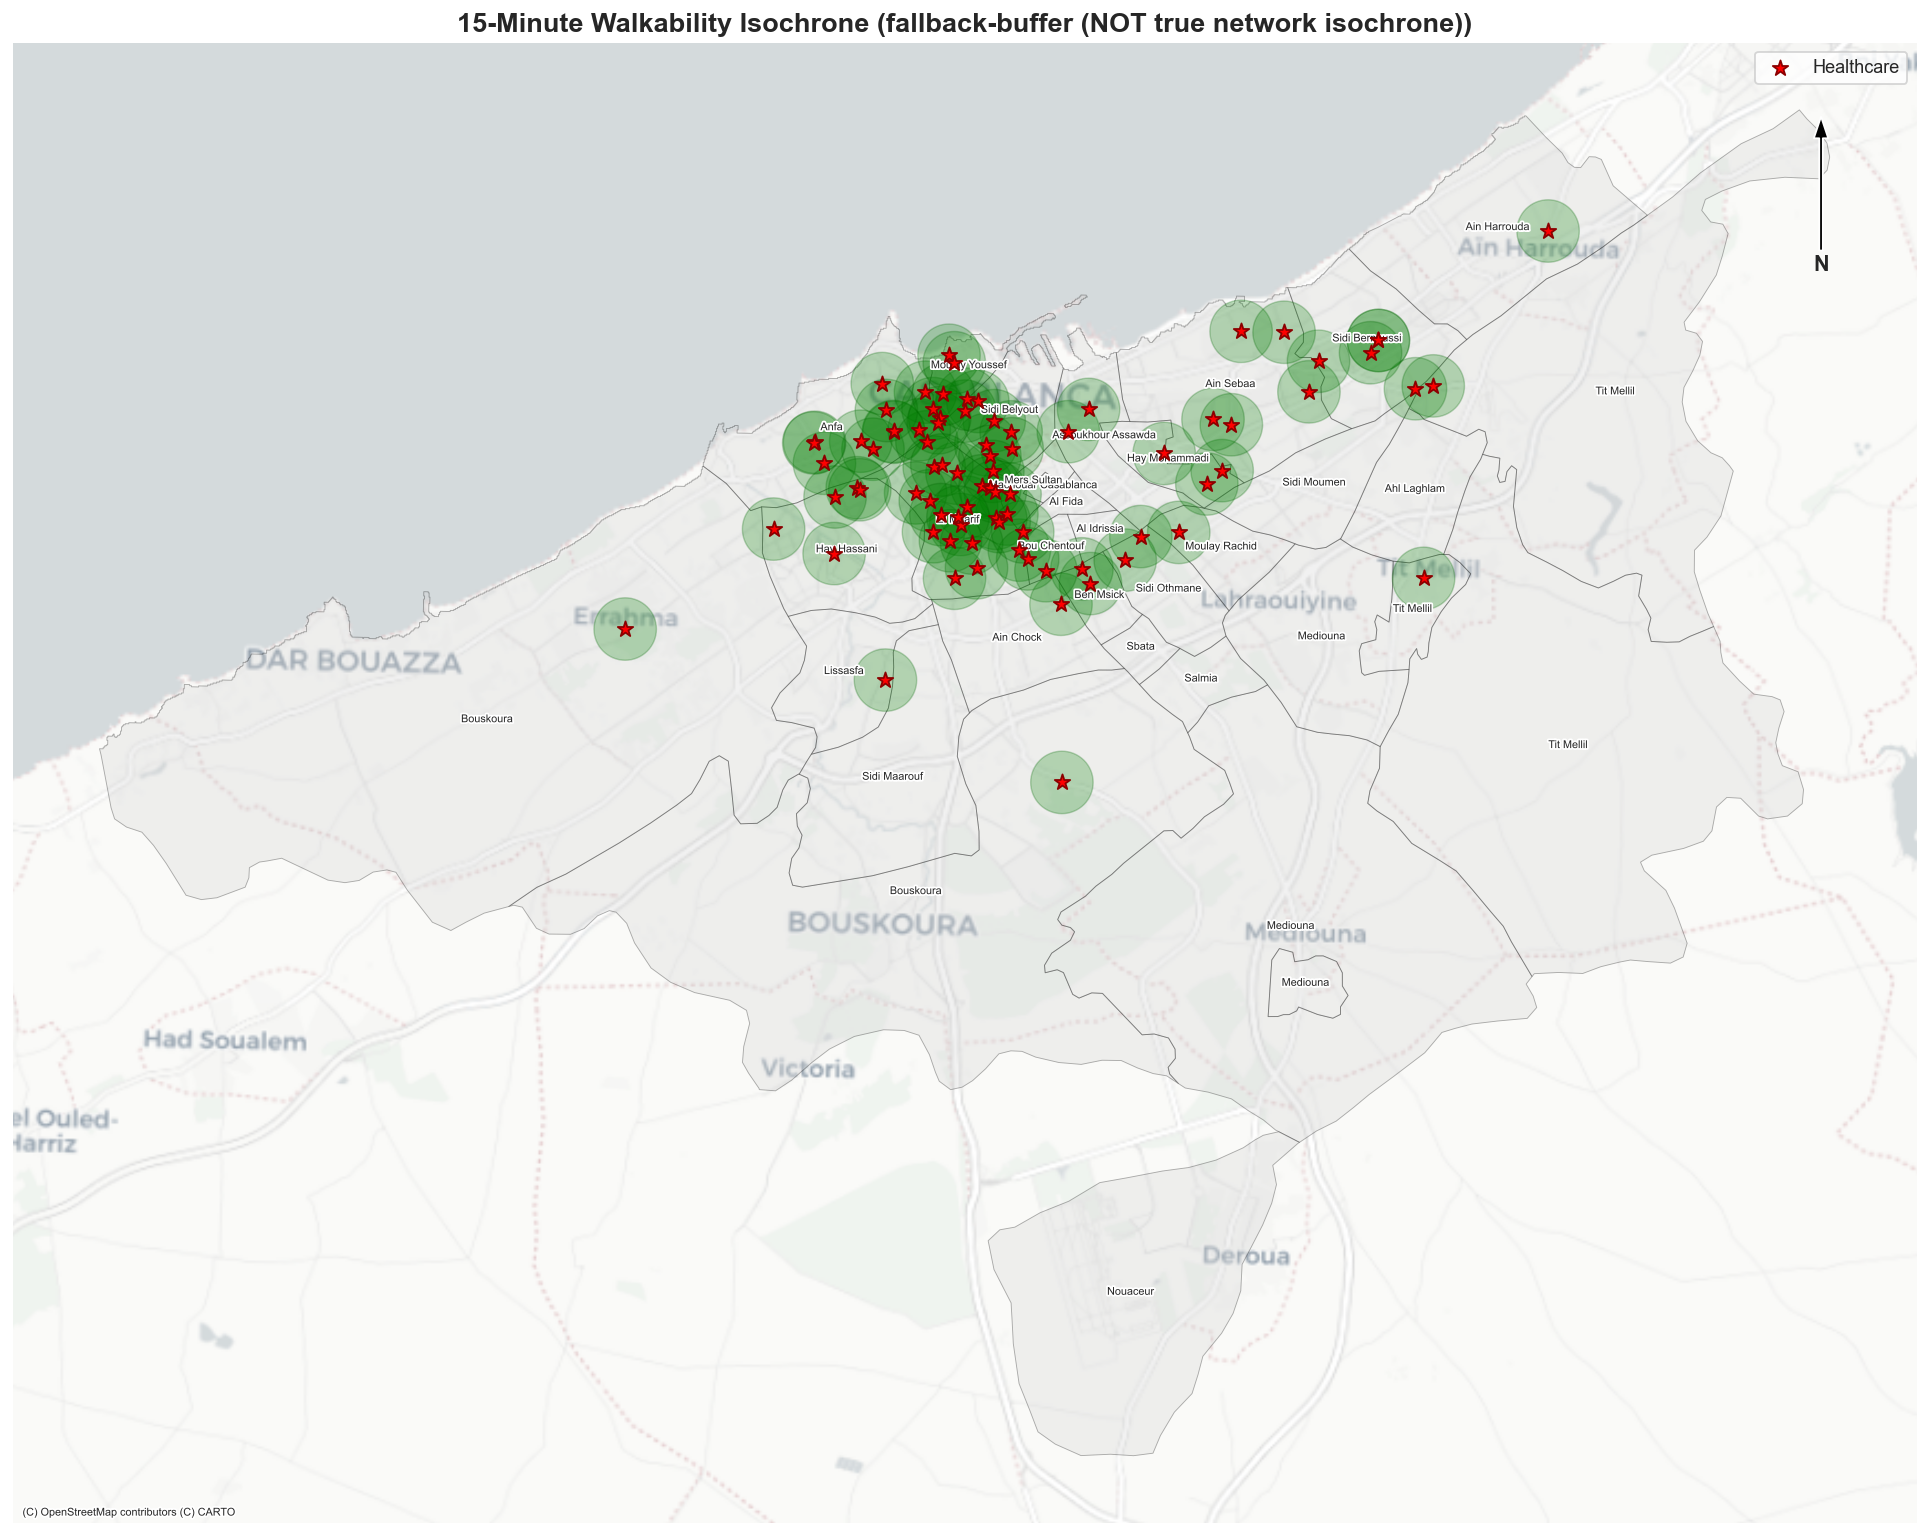

✓ Isochrone map created using: fallback-buffer (NOT true network isochrone)


In [97]:
def create_network_isochrones(hospitals_gdf, districts_gdf, minutes=15):
    '''
    Build 15-min walkability isochrones from OSMnx walk network.
    Falls back to geometric buffers when OSM network is unavailable.
    '''
    hospitals_geo = hospitals_gdf.to_crs(CRS_GEO)
    districts_geo = districts_gdf.to_crs(CRS_GEO)
    isochrone_polys = []
    method_label = 'network-isochrone'
    distance_m = minutes * WALKING_SPEED_M_MIN

    try:
        minx, miny, maxx, maxy = districts_geo.total_bounds
        pad = 0.02
        # G_walk = ox.graph_from_bbox(maxy + pad, miny - pad, maxx + pad, minx - pad, network_type='walk')
        G_walk = ox.graph_from_bbox(
            north=maxy+pad,
            south=miny-pad,
            east=maxx+pad,
            west=minx-pad,
            network_type='walk'
        )
        G_walk = ox.project_graph(G_walk, to_crs=CRS_METRIC)
        nodes_proj = ox.graph_to_gdfs(G_walk, edges=False)

        for _, hrow in hospitals_gdf.to_crs(CRS_METRIC).iterrows():
            nearest_node = nodes_proj.distance(hrow.geometry).idxmin()
            sub = nx.ego_graph(G_walk, nearest_node, radius=distance_m, distance='length')
            if len(sub.nodes) == 0:
                isochrone_polys.append(hrow.geometry.buffer(distance_m))
                continue
            node_points = [Point((data['x'], data['y'])) for _, data in sub.nodes(data=True)]
            isochrone_polys.append(gpd.GeoSeries(node_points, crs=CRS_METRIC).unary_union.convex_hull)
    except Exception as exc:
        method_label = 'fallback-buffer (NOT true network isochrone)'
        warnings.warn(f'OSM walk network unavailable, using fallback geometric buffers: {exc}')
        isochrone_polys = [geom.buffer(distance_m) for geom in hospitals_gdf.to_crs(CRS_METRIC).geometry]

    return gpd.GeoDataFrame(
                {'method': [method_label] * len(isochrone_polys)},
                geometry=isochrone_polys,
                crs=CRS_METRIC
            )


print('Creating 15-minute walkability isochrones...')
isochrone_15 = create_network_isochrones(hospitals, districts, minutes=15)

fig, ax = plt.subplots(figsize=(15, 12))
districts.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, linewidth=0.5)
isochrone_15.plot(ax=ax, color='green', alpha=0.25, edgecolor='darkgreen', linewidth=0.8, label='15-min walkability')
hospitals.plot(ax=ax, color='red', markersize=80, marker='*', edgecolor='darkred', linewidth=1, label='Healthcare', zorder=5)

name_col = 'district' if 'district' in districts.columns else 'commune'
for _, row in districts.iterrows():
    ax.annotate(
        str(row[name_col]),
        xy=(row['centroid'].x, row['centroid'].y),
        fontsize=6,
        ha='center',
        path_effects=[pe.withStroke(linewidth=2, foreground='white')],
    )

add_web_basemap(ax, districts)
add_north_arrow(ax)
method_used = isochrone_15['method'].iloc[0]
ax.set_title(f'15-Minute Walkability Isochrone ({method_used})', fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.axis('off')

plt.tight_layout()
plt.show()
print(f'✓ Isochrone map created using: {method_used}')


## 7. Accessibility Visualization

### 7.1 Figure Styling Strategy for Report-Ready Maps

To improve readability and academic presentation quality, the following visualization refinements are applied consistently:

- clearer district boundaries and lower background clutter
- selective district labeling (largest districts only) to reduce overlap
- concise, policy-oriented titles
- cleaner legends with explicit units
- threshold-aware color choices for accessibility interpretation

This preserves the original analytical logic while improving figure communication quality for the interim report.

In [98]:
# Reusable styling helpers for cleaner academic maps

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})


def add_selective_labels(ax, gdf, label_col, top_n=12, area_col='area_km2', fontsize=6):
    """Annotate only the largest polygons to reduce label overlap."""
    if area_col in gdf.columns:
        label_df = gdf.nlargest(top_n, area_col)
    else:
        label_df = gdf.copy()

    for _, row in label_df.iterrows():
        pt = row.geometry.representative_point()
        ax.annotate(
            str(row[label_col]),
            xy=(pt.x, pt.y),
            fontsize=fontsize,
            ha='center',
            va='center',
            color='black',
            path_effects=[pe.withStroke(linewidth=2.0, foreground='white')],
            zorder=6,
        )


def plot_choropleth_map(
    gdf,
    value_col,
    title,
    legend_label,
    cmap,
    label_col,
    vmin=None,
    vmax=None,
    threshold=None,
    threshold_label=None,
    hospitals_gdf=None,
):
    fig, ax = plt.subplots(figsize=(11, 9))

    gdf.plot(
        column=value_col,
        cmap=cmap,
        linewidth=0.9,
        edgecolor='#3f3f3f',
        legend=True,
        legend_kwds={
            'label': legend_label,
            'shrink': 0.75,
            'format': '%.1f',
        },
        ax=ax,
        alpha=0.95,
        vmin=vmin,
        vmax=vmax,
    )

    if hospitals_gdf is not None:
        hospitals_gdf.plot(
            ax=ax,
            color='#1f4e79',
            markersize=36,
            marker='*',
            edgecolor='white',
            linewidth=0.5,
            zorder=7,
            alpha=0.9,
            label='Healthcare facility',
        )

    add_selective_labels(ax, gdf, label_col=label_col, top_n=12, fontsize=6)
    add_web_basemap(ax, gdf)
    add_north_arrow(ax)

    if threshold is not None:
        ax.text(
            0.02,
            0.02,
            threshold_label,
            transform=ax.transAxes,
            fontsize=9,
            color='#222222',
            bbox=dict(facecolor='white', edgecolor='#999999', alpha=0.85, boxstyle='round,pad=0.3'),
        )

    ax.set_title(title, pad=12)
    ax.axis('off')

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, loc='lower left', frameon=True, framealpha=0.9)

    plt.tight_layout()
    return fig, ax

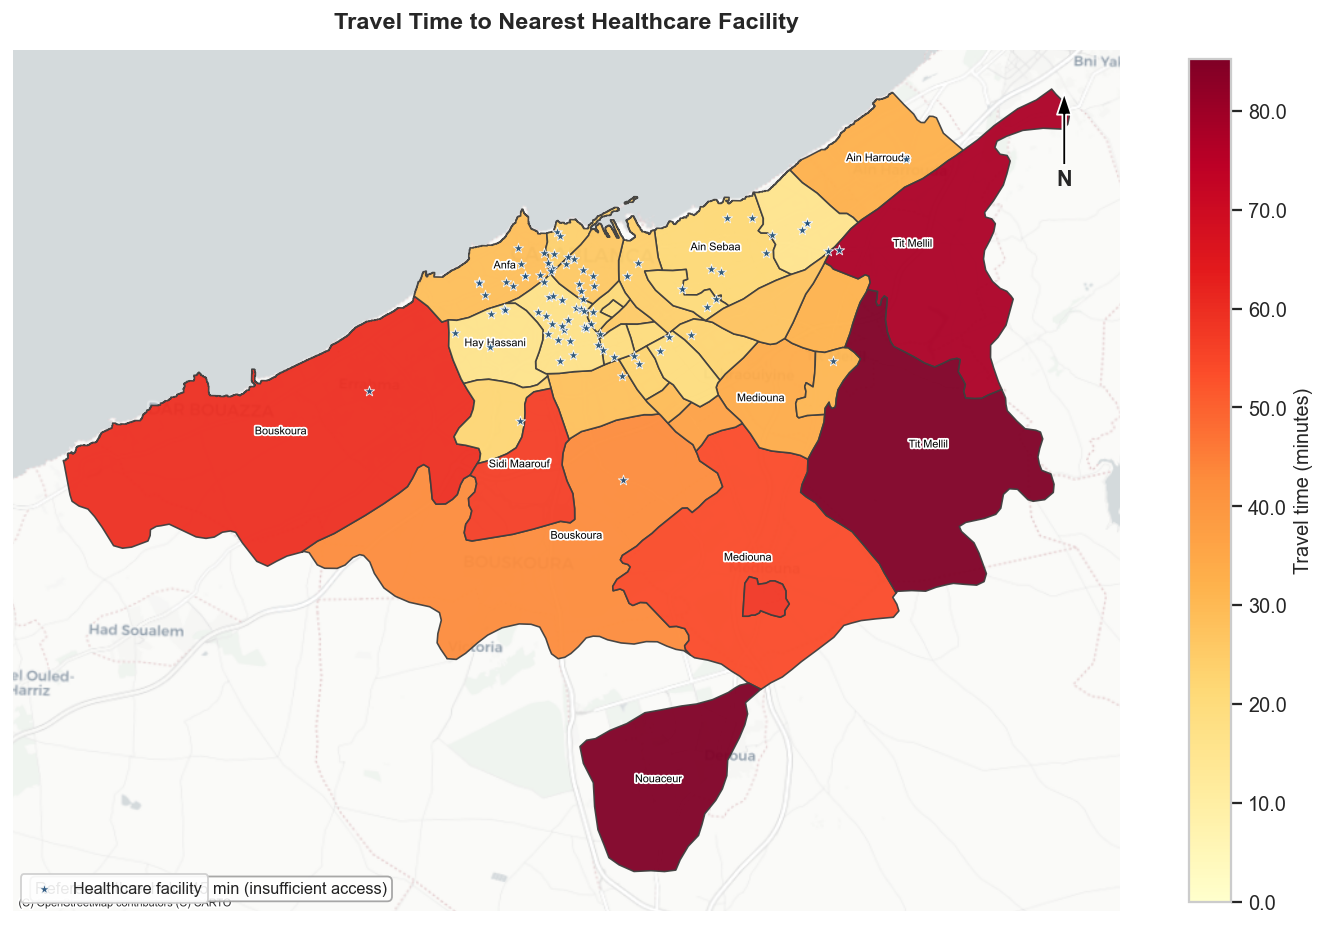

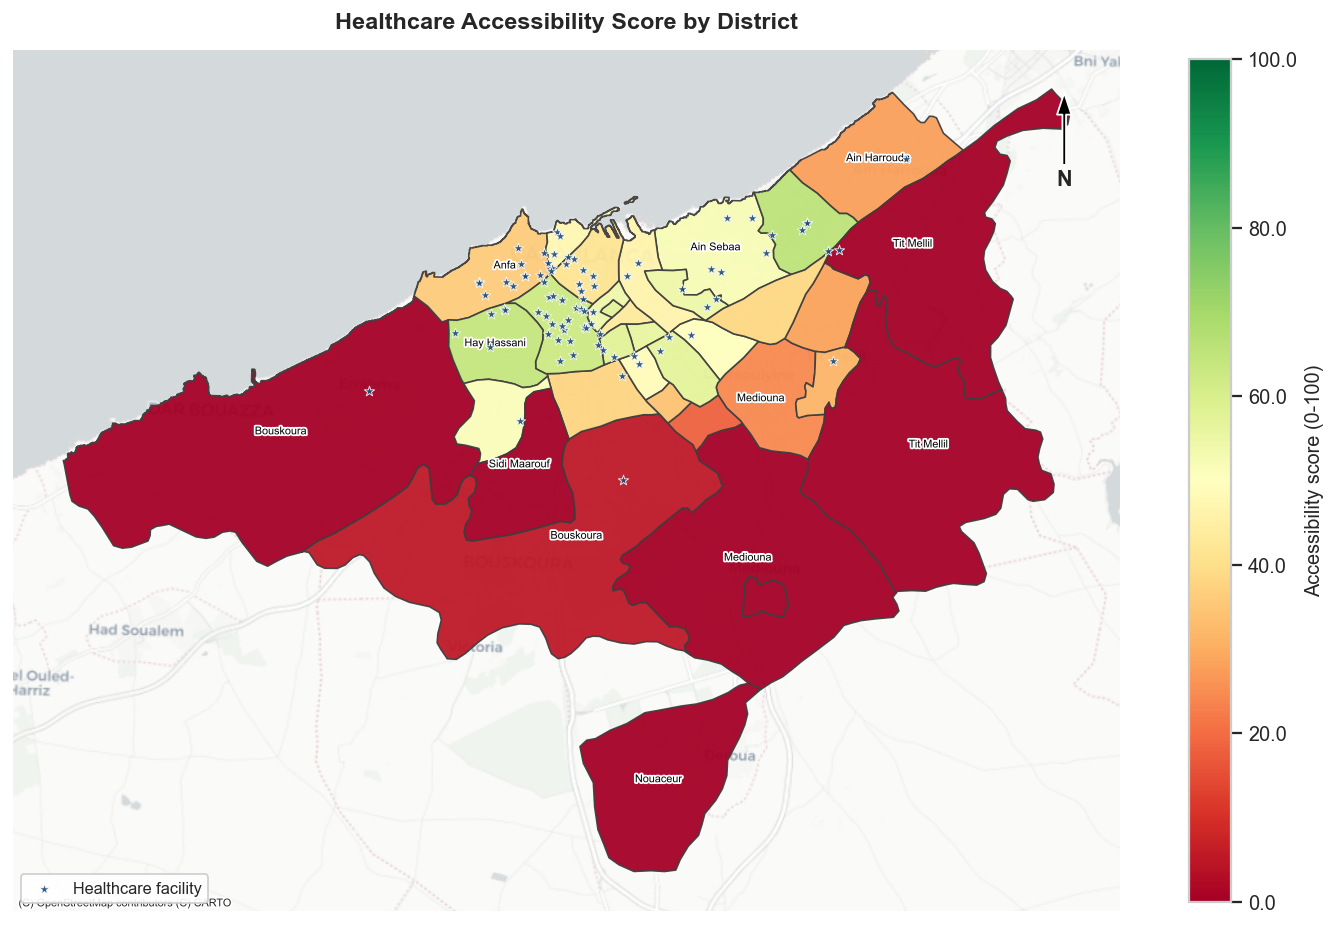

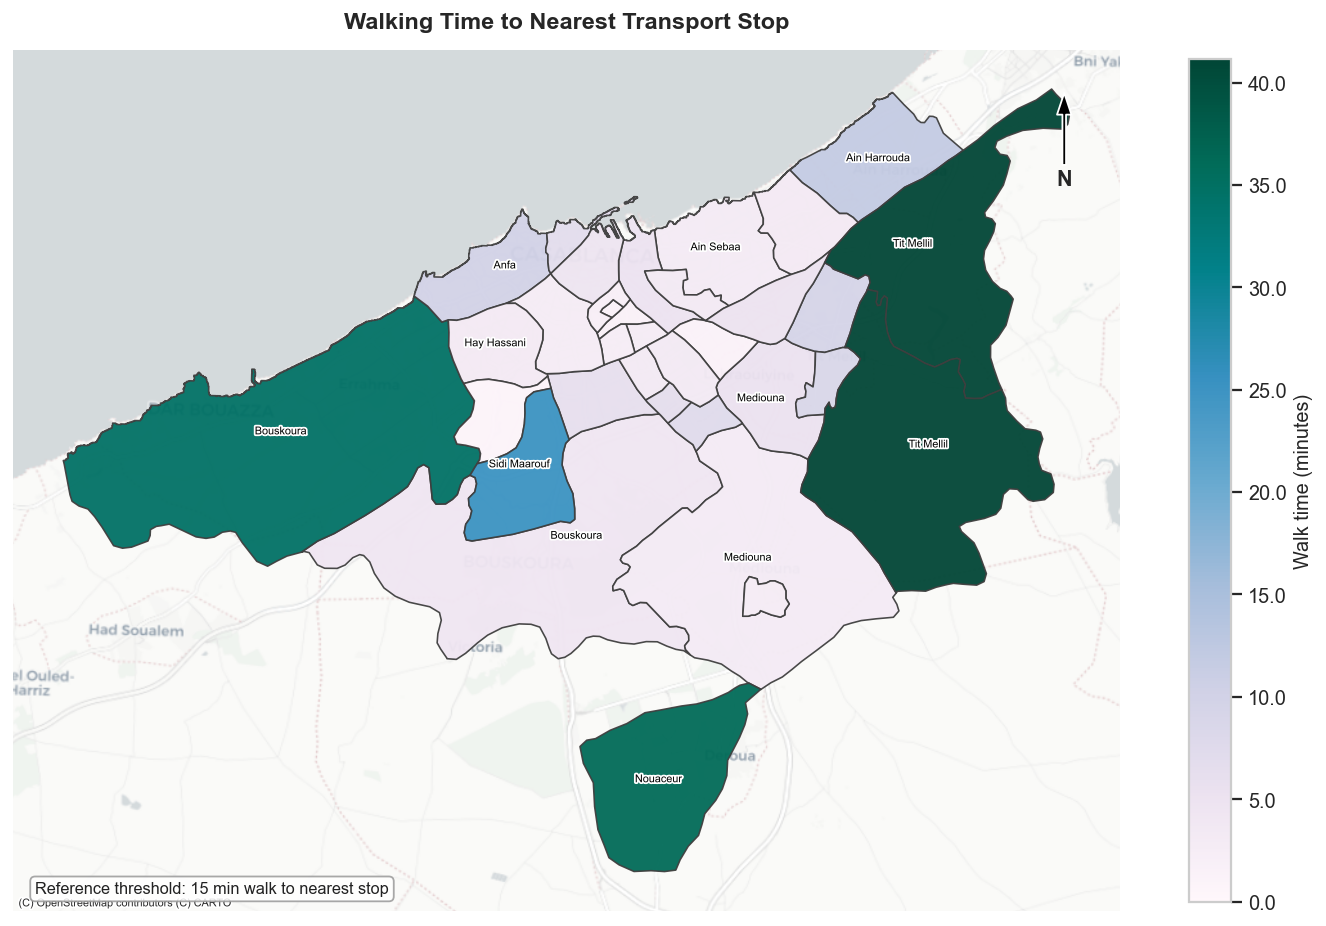

✓ Report-ready choropleths created: travel time, accessibility score, and walking time


In [99]:
# Improved report-ready choropleths: travel time, accessibility score, and walking time
name_col = 'district' if 'district' in districts.columns else 'commune'

# Map 1: Total travel time (policy threshold at 45 min)
fig1, ax1 = plot_choropleth_map(
    gdf=districts,
    value_col='total_travel_time_min',
    title='Travel Time to Nearest Healthcare Facility',
    legend_label='Travel time (minutes)',
    cmap='YlOrRd',
    label_col=name_col,
    vmin=0,
    vmax=max(45, np.nanpercentile(districts['total_travel_time_min'], 95)),
    threshold=45,
    threshold_label='Reference threshold: 45 min (insufficient access)',
    hospitals_gdf=hospitals,
)
plt.savefig(ANALYSIS_OUTPUT_DIR / 'map_travel_time_report.png', bbox_inches='tight')
plt.show()

# Map 2: Accessibility score (0-100, higher is better)
fig2, ax2 = plot_choropleth_map(
    gdf=districts,
    value_col='accessibility_score',
    title='Healthcare Accessibility Score by District',
    legend_label='Accessibility score (0-100)',
    cmap='RdYlGn',
    label_col=name_col,
    vmin=0,
    vmax=100,
    hospitals_gdf=hospitals,
)
plt.savefig(ANALYSIS_OUTPUT_DIR / 'map_accessibility_score_report.png', bbox_inches='tight')
plt.show()

# Map 3: Walk time to nearest stop (threshold at 15 min)
fig3, ax3 = plot_choropleth_map(
    gdf=districts,
    value_col='walk_time_to_stop_min',
    title='Walking Time to Nearest Transport Stop',
    legend_label='Walk time (minutes)',
    cmap='PuBuGn',
    label_col=name_col,
    vmin=0,
    vmax=max(15, np.nanpercentile(districts['walk_time_to_stop_min'], 95)),
    threshold=15,
    threshold_label='Reference threshold: 15 min walk to nearest stop',
    hospitals_gdf=None,
)
plt.savefig(ANALYSIS_OUTPUT_DIR / 'map_walk_time_to_stop_report.png', bbox_inches='tight')
plt.show()

print('✓ Report-ready choropleths created: travel time, accessibility score, and walking time')

### Interpretation: Spatial Pattern of Accessibility Scores

The dual maps compare raw travel burden and normalized accessibility scores.
A recurring center-periphery contrast indicates that residents in outer districts may require more time to reach care, even when city-wide averages appear acceptable.

This visual evidence supports targeted interventions rather than uniform city-wide policy responses.

## 8. Equity Analysis

Analyze accessibility in relation to population

In [100]:
def weighted_gini(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = (~np.isnan(values)) & (~np.isnan(weights)) & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    values, weights = values[mask], weights[mask]
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cw = np.cumsum(weights)
    cxw = np.cumsum(values * weights)
    if cxw[-1] == 0:
        return 0.0
    g = np.sum((cxw / cxw[-1])[1:] * (cw[:-1] / cw[-1]) - (cxw[:-1] / cxw[-1]) * (cw[1:] / cw[-1]))
    return abs(g)

In [101]:
districts_with_population['accessibility_score'] = districts['accessibility_score'].copy()
districts_with_population['total_travel_time_min'] = districts['total_travel_time_min'].copy()

EQUITY ANALYSIS

Total population: 5,102,619
Population with poor accessibility (<50 score): 3,228,525
Percentage affected: 63.3%
Population-weighted average travel time: 32.4 minutes
Population-weighted Gini (accessibility_score): 0.322


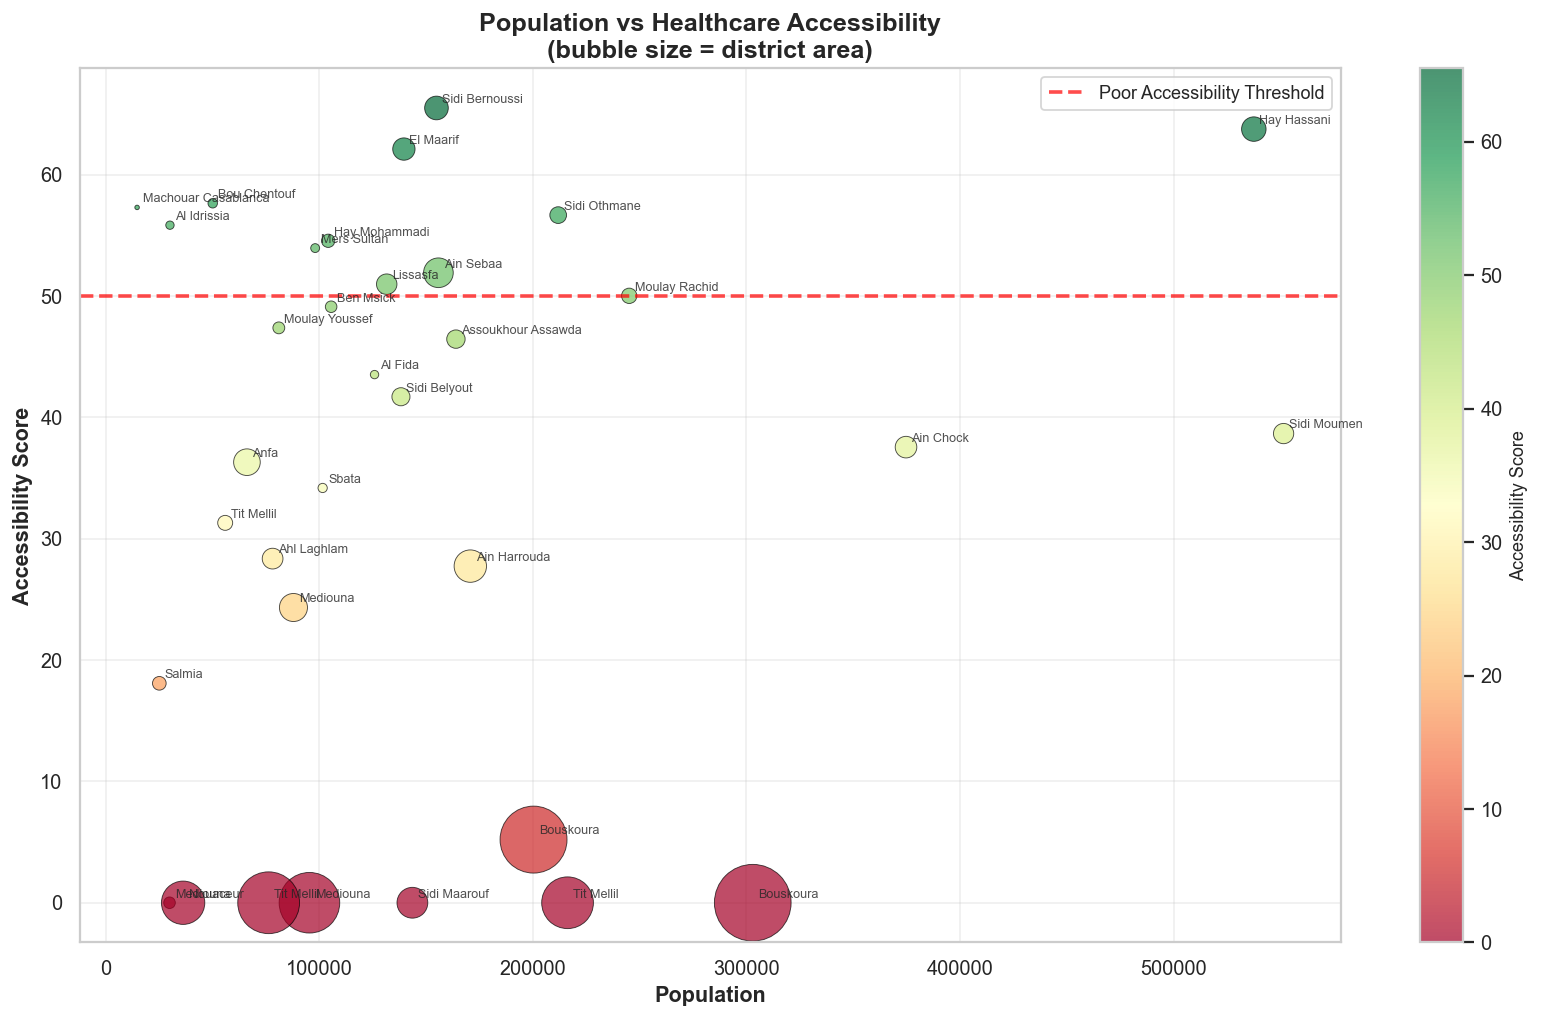

In [102]:
if 'population' in districts_with_population.columns:
    poor_access = districts_with_population['accessibility_score'] < 50
    pop_poor_access = districts_with_population[poor_access]['population'].sum()
    total_pop = districts_with_population['population'].sum()

    weighted_travel_time = np.average(
        districts_with_population['total_travel_time_min'].fillna(ACCESSIBILITY_MAX_TIME),
        weights=districts_with_population['population'],
    )
    pop_weighted_gini = weighted_gini(districts_with_population['accessibility_score'], districts_with_population['population'])

    print('=' * 60)
    print('EQUITY ANALYSIS')
    print('=' * 60)
    print(f'\nTotal population: {total_pop:,.0f}')
    print(f'Population with poor accessibility (<50 score): {pop_poor_access:,.0f}')
    print(f'Percentage affected: {100 * pop_poor_access / total_pop:.1f}%')
    print(f'Population-weighted average travel time: {weighted_travel_time:.1f} minutes')
    print(f'Population-weighted Gini (accessibility_score): {pop_weighted_gini:.3f}')

    districts_with_population['pop_weighted_gini'] = pop_weighted_gini

    fig, ax = plt.subplots(figsize=(13, 8))
    scatter = ax.scatter(
        districts_with_population['population'],
        districts_with_population['accessibility_score'],
        c=districts_with_population['accessibility_score'],
        s=districts_with_population['area_km2'] * 12,
        cmap='RdYlGn',
        alpha=0.7,
        edgecolor='black',
        linewidth=0.5,
    )

    district_name_col = 'district' if 'district' in districts_with_population.columns else 'commune'
    for _, row in districts_with_population.iterrows():
        ax.annotate(
            str(row[district_name_col]),
            (row['population'], row['accessibility_score']),
            fontsize=7,
            alpha=0.8,
            xytext=(3, 3),
            textcoords='offset points',
        )

    ax.axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Poor Accessibility Threshold')
    ax.set_xlabel('Population', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accessibility Score', fontsize=12, fontweight='bold')
    ax.set_title('Population vs Healthcare Accessibility\n(bubble size = district area)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Accessibility Score', fontsize=10)

    plt.tight_layout()
    plt.show()


### Interpretation: Equity Implications

Population-weighted indicators translate accessibility into social impact.
Even moderate geographic disparities can affect a large number of residents when they occur in high-population districts.

This section therefore moves from spatial description to distributive equity: who is most affected and where.

✓ 2SFCA scores computed (30-min catchment with decay)
count    34.000000
mean      0.000022
std       0.000042
min       0.000000
25%       0.000000
50%       0.000002
75%       0.000021
max       0.000172
Name: score_2sfca, dtype: float64


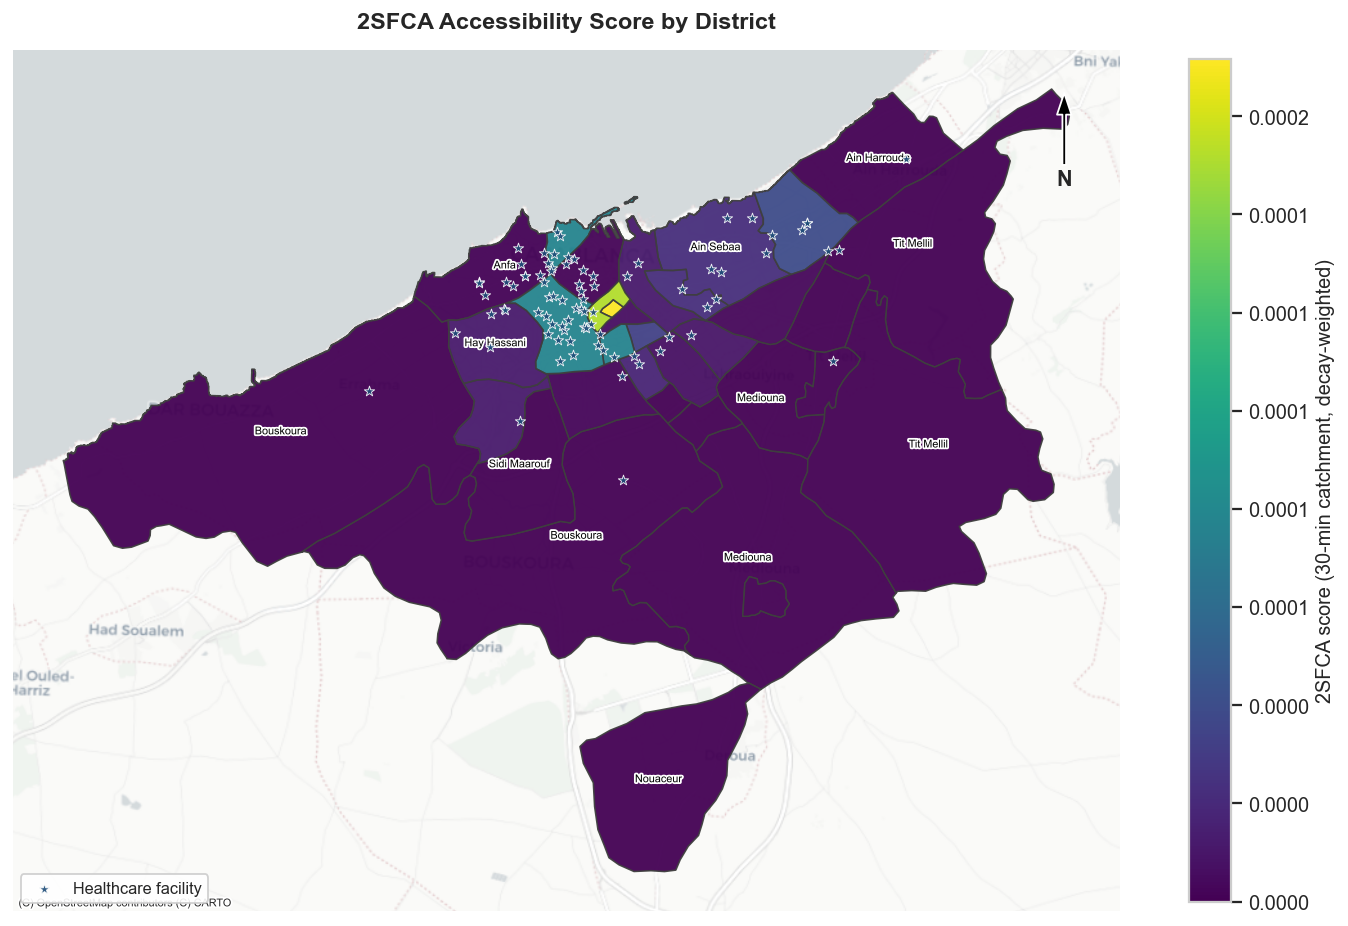


Sensitivity analysis (bus speed ±20%) ranking changes:


,district,rank_change_slow_vs_base,rank_change_fast_vs_base
30,Sidi Othmane,6.0,6.0
9,Al Idrissia,6.0,6.0
14,El Maarif,4.0,3.0
26,Sidi Belyout,3.0,1.0
2,Mediouna,2.0,0.0
21,Moulay Rachid,2.0,-1.0
27,Sidi Bernoussi,2.0,3.0
25,Sbata,1.0,-1.0
19,Mediouna,1.0,-1.0
29,Sidi Moumen,1.0,1.0


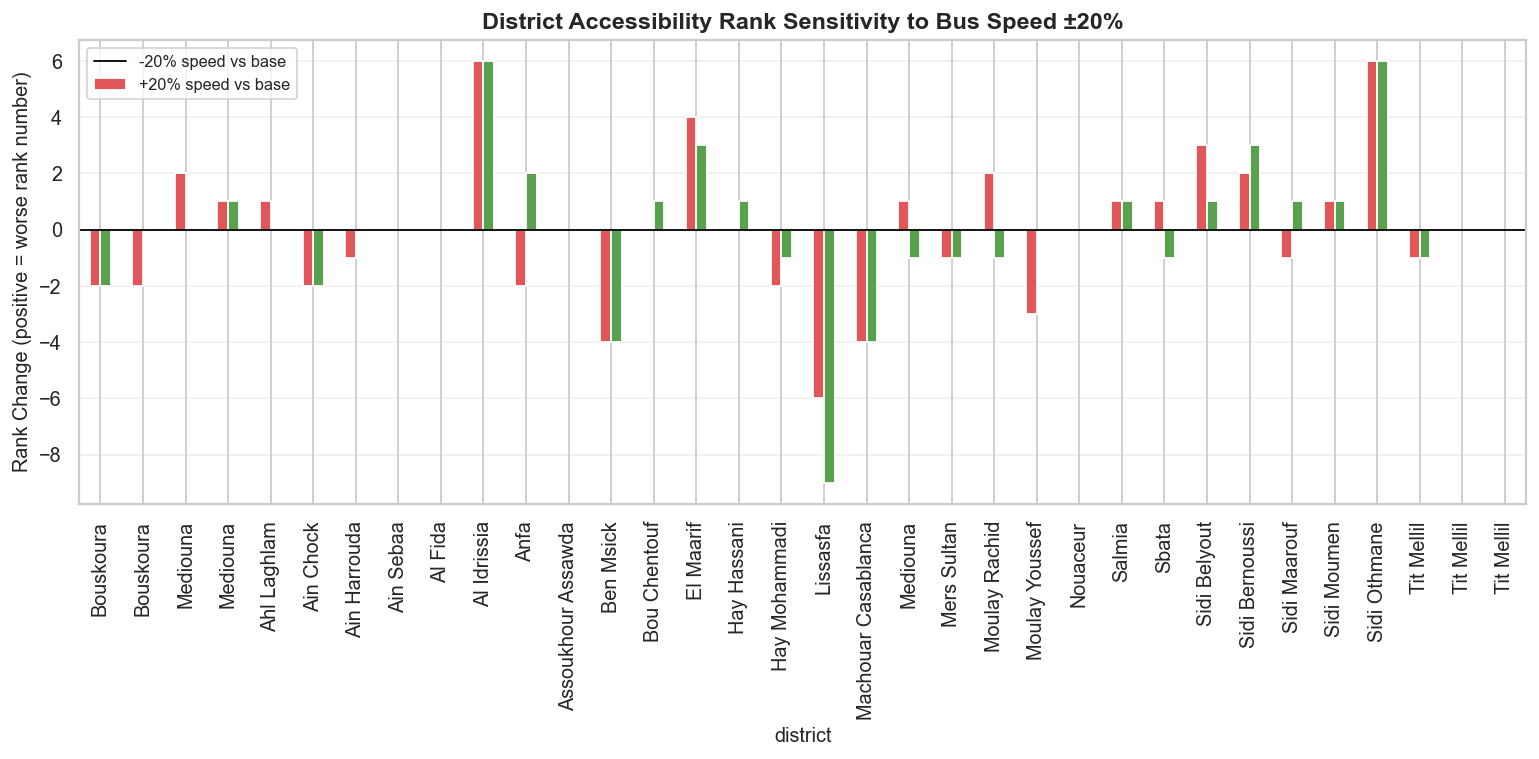

In [103]:
# 2SFCA accessibility (30-min catchment with distance-decay)
CATCHMENT_MIN = 30


def distance_decay(travel_time, catchment=CATCHMENT_MIN):
    if pd.isna(travel_time) or travel_time > catchment:
        return 0.0
    return np.exp(-(travel_time / catchment) ** 2)


district_stop_nodes = [f"stop_{stops.index[int(i)]}" for i in np.atleast_1d(stop_indices)]

travel_time_matrix = pd.DataFrame(index=districts.index, columns=health_nodes, dtype=float)
for d_pos, d_idx in enumerate(districts.index):
    stop_node = district_stop_nodes[d_pos]
    walk_to_stop = districts.loc[d_idx, 'walk_time_to_stop_min']
    for h_node in health_nodes:
        try:
            transit_plus_walk = nx.shortest_path_length(G, stop_node, h_node, weight='weight')
            travel_time_matrix.loc[d_idx, h_node] = walk_to_stop + WAIT_TIME + transit_plus_walk
        except nx.NetworkXNoPath:
            travel_time_matrix.loc[d_idx, h_node] = np.nan

# Step 1: provider-to-population ratio at each facility
facility_ratios = {}
for h_node in health_nodes:
    tt_col = travel_time_matrix[h_node]
    weights = tt_col.apply(distance_decay)
    demand = (districts_with_population['population'] * weights).sum()
    facility_ratios[h_node] = 1.0 / demand if demand > 0 else 0.0

# Step 2: district accessibility score from all reachable facilities
districts_with_population['score_2sfca'] = 0.0
for d_idx in districts_with_population.index:
    total_score = 0.0
    for h_node in health_nodes:
        tt = travel_time_matrix.loc[d_idx, h_node]
        total_score += facility_ratios[h_node] * distance_decay(tt)
    districts_with_population.loc[d_idx, 'score_2sfca'] = total_score

# Keep an alias expected in reports/requests
districts_with_population['2sfca_score'] = districts_with_population['score_2sfca']

# Align districts table with computed 2SFCA scores for later summaries/plots
districts['score_2sfca'] = districts_with_population['score_2sfca'].reindex(districts.index)
districts['2sfca_score'] = districts['score_2sfca']

print('✓ 2SFCA scores computed (30-min catchment with decay)')
print(districts_with_population['score_2sfca'].describe())

# Improved 2SFCA choropleth for report
name_col = 'district' if 'district' in districts_with_population.columns else 'commune'
fig, ax = plt.subplots(figsize=(11, 9))

districts_with_population.plot(
    column='score_2sfca',
    cmap='viridis',
    legend=True,
    legend_kwds={
        'label': '2SFCA score (30-min catchment, decay-weighted)',
        'shrink': 0.75,
        'format': '%.4f',
    },
    edgecolor='#3f3f3f',
    linewidth=0.9,
    alpha=0.95,
    ax=ax,
)

hospitals.plot(
    ax=ax,
    color='#1f4e79',
    markersize=36,
    marker='*',
    edgecolor='white',
    linewidth=0.5,
    zorder=7,
    alpha=0.9,
    label='Healthcare facility',
)

add_selective_labels(ax, districts_with_population, label_col=name_col, top_n=12, fontsize=6)
add_web_basemap(ax, districts_with_population)
add_north_arrow(ax)
ax.set_title('2SFCA Accessibility Score by District', pad=12)
ax.axis('off')

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, loc='lower left', frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'map_2sfca_accessibility_report.png', bbox_inches='tight')
plt.show()

# Sensitivity analysis: bus speed ±20%
def run_speed_sensitivity(speed_factor):
    speed_m_min = BUS_SPEED_M_MIN * speed_factor
    times = []
    for i in range(len(origin_points)):
        nearest_stop_idx = stop_indices[i] if isinstance(stop_indices[i], (int, np.integer)) else stop_indices[i][0]
        stop_node = f'stop_{nearest_stop_idx}'
        best = np.inf
        for h_node in health_nodes:
            try:
                base_path = nx.shortest_path_length(G, stop_node, h_node, weight='distance')
                total = districts['walk_time_to_stop_min'].iloc[i] + WAIT_TIME + (base_path / speed_m_min)
                if total < best:
                    best = total
            except nx.NetworkXNoPath:
                pass
        times.append(np.nan if np.isinf(best) else best)
    return np.array(times)


sensitivity = pd.DataFrame(index=districts.index)
sensitivity['tt_slow'] = run_speed_sensitivity(0.8)
sensitivity['tt_base'] = districts['total_travel_time_min'].values
sensitivity['tt_fast'] = run_speed_sensitivity(1.2)

for c in ['tt_slow', 'tt_base', 'tt_fast']:
    sensitivity[f'rank_{c}'] = pd.Series(sensitivity[c], index=districts.index).rank(method='min', ascending=True)

sensitivity['rank_change_slow_vs_base'] = sensitivity['rank_tt_slow'] - sensitivity['rank_tt_base']
sensitivity['rank_change_fast_vs_base'] = sensitivity['rank_tt_fast'] - sensitivity['rank_tt_base']

district_name_col = 'district' if 'district' in districts_with_population.columns else 'commune'
rank_change_df = districts_with_population[[district_name_col]].join(
    sensitivity[['rank_change_slow_vs_base', 'rank_change_fast_vs_base']]
)

print('\nSensitivity analysis (bus speed ±20%) ranking changes:')
display(rank_change_df.sort_values('rank_change_slow_vs_base', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = rank_change_df.set_index(district_name_col)[['rank_change_slow_vs_base', 'rank_change_fast_vs_base']]
plot_df.plot(kind='bar', ax=ax, color=['#E15759', '#59A14F'])
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Rank Change (positive = worse rank number)')
ax.set_title('District Accessibility Rank Sensitivity to Bus Speed ±20%')
ax.legend(['-20% speed vs base', '+20% speed vs base'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9.2 Sensitivity Analysis (Bus Speed ±20%)

Travel times are recomputed under slower and faster bus operating assumptions to test ranking robustness.

## 9.4 Additional Diagnostic Plots for Interim Report

The following compact diagnostics are added to strengthen interpretation and reporting quality:

1. **Travel-time distribution** to show skewness and districts beyond 45-minute policy threshold.
2. **Accessibility score distribution** (histogram + boxplot) to summarize central tendency and dispersion.
3. **Walking-time distribution** to assess first-mile burden relative to the 15-minute benchmark.
4. **Travel time vs 2SFCA relationship** to test consistency between burden-based and supply-demand indicators.
5. **Threshold exceedance bar chart** to identify districts requiring priority intervention.

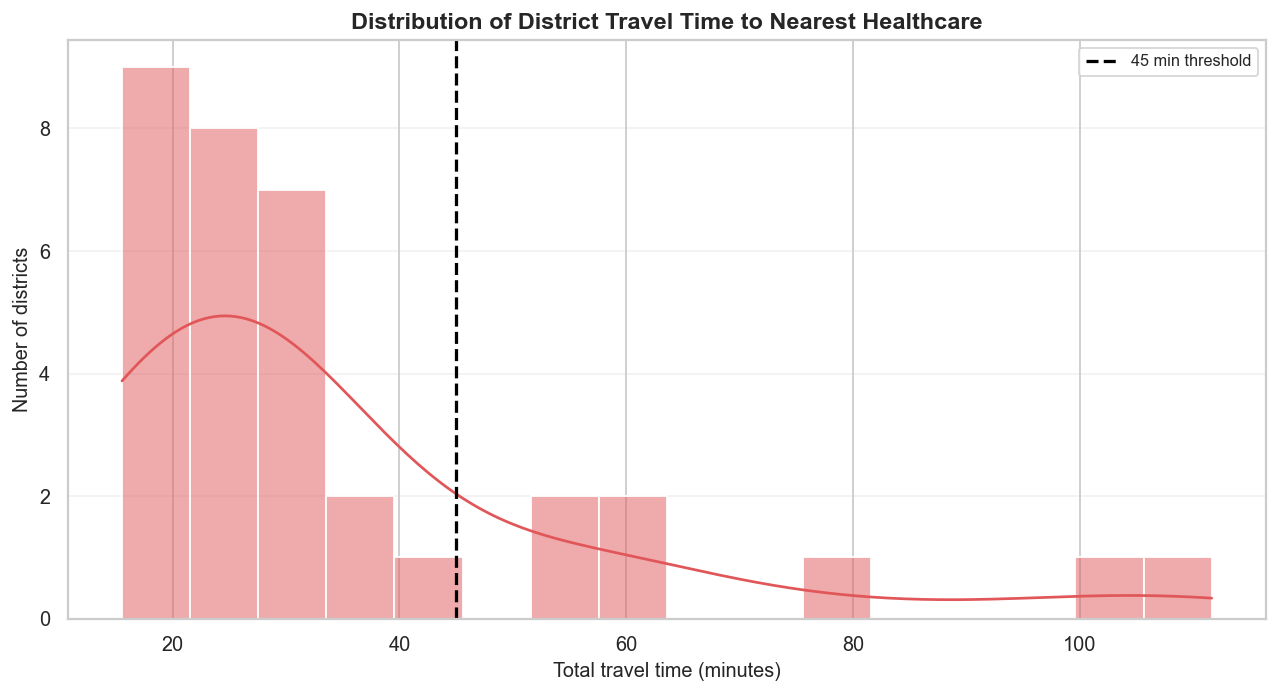

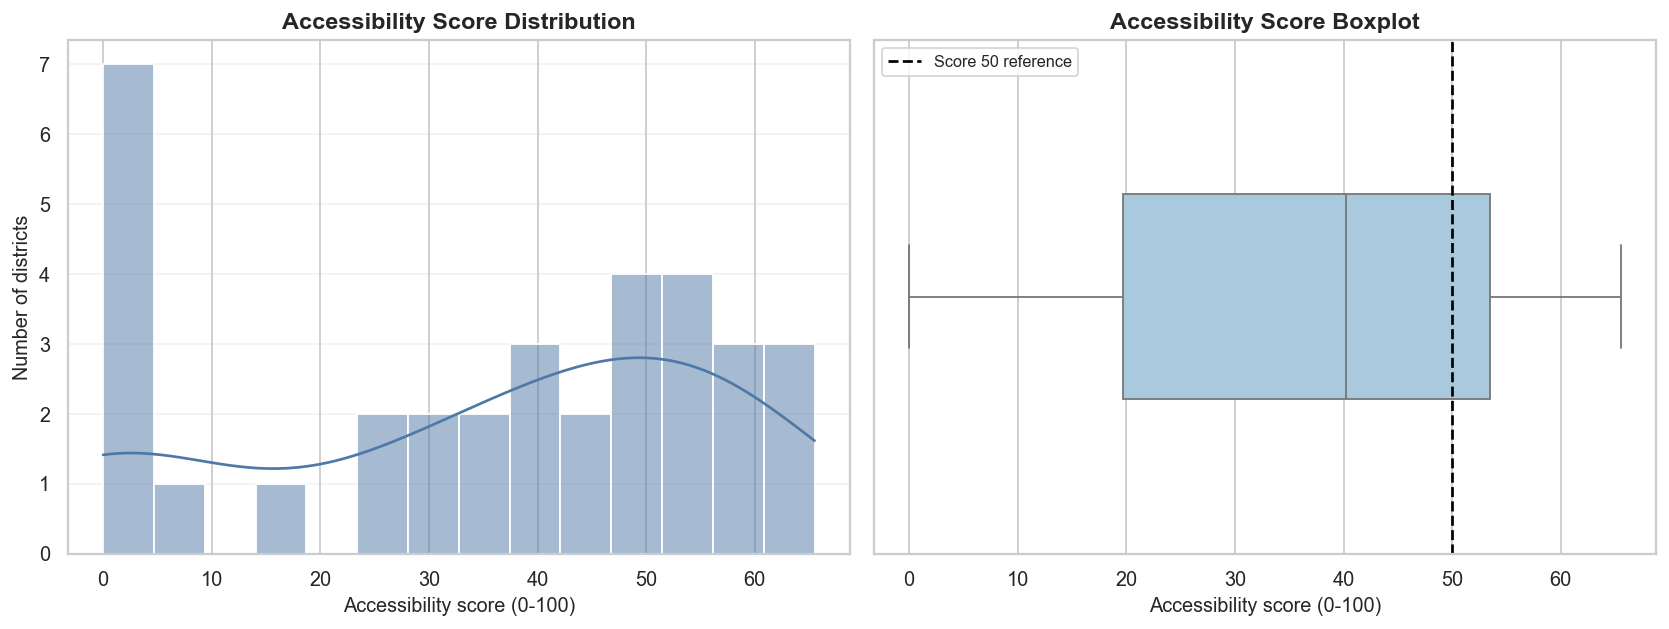

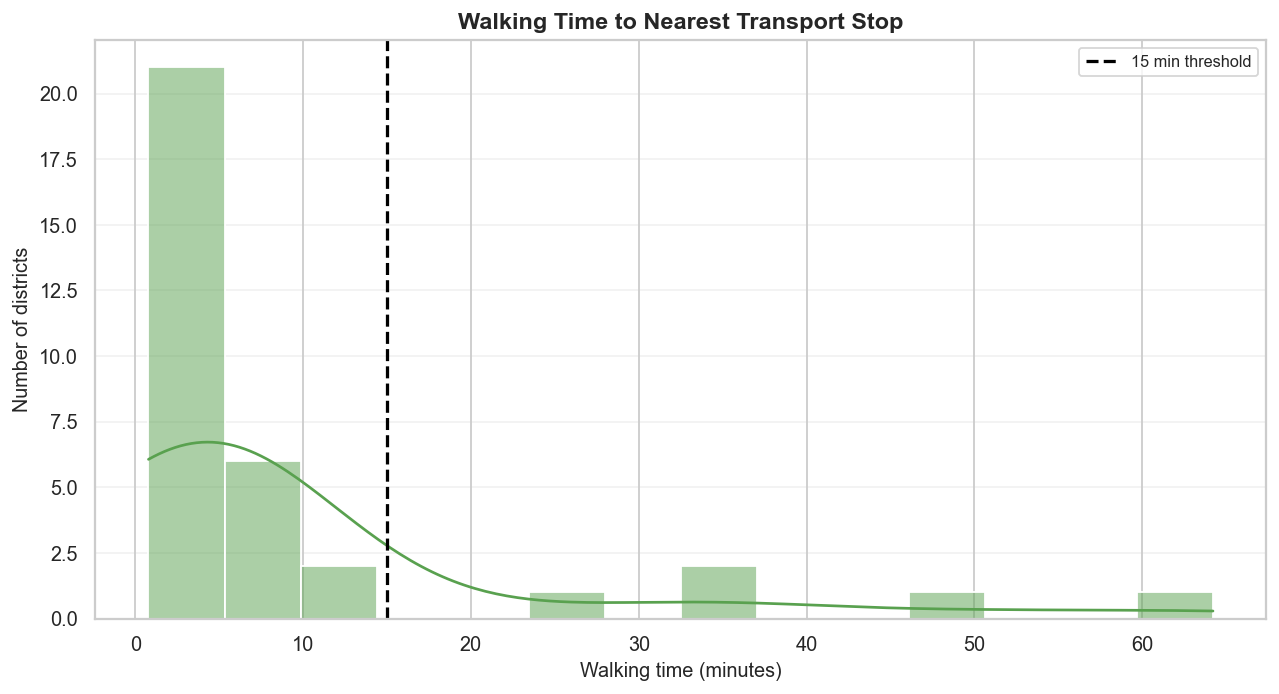

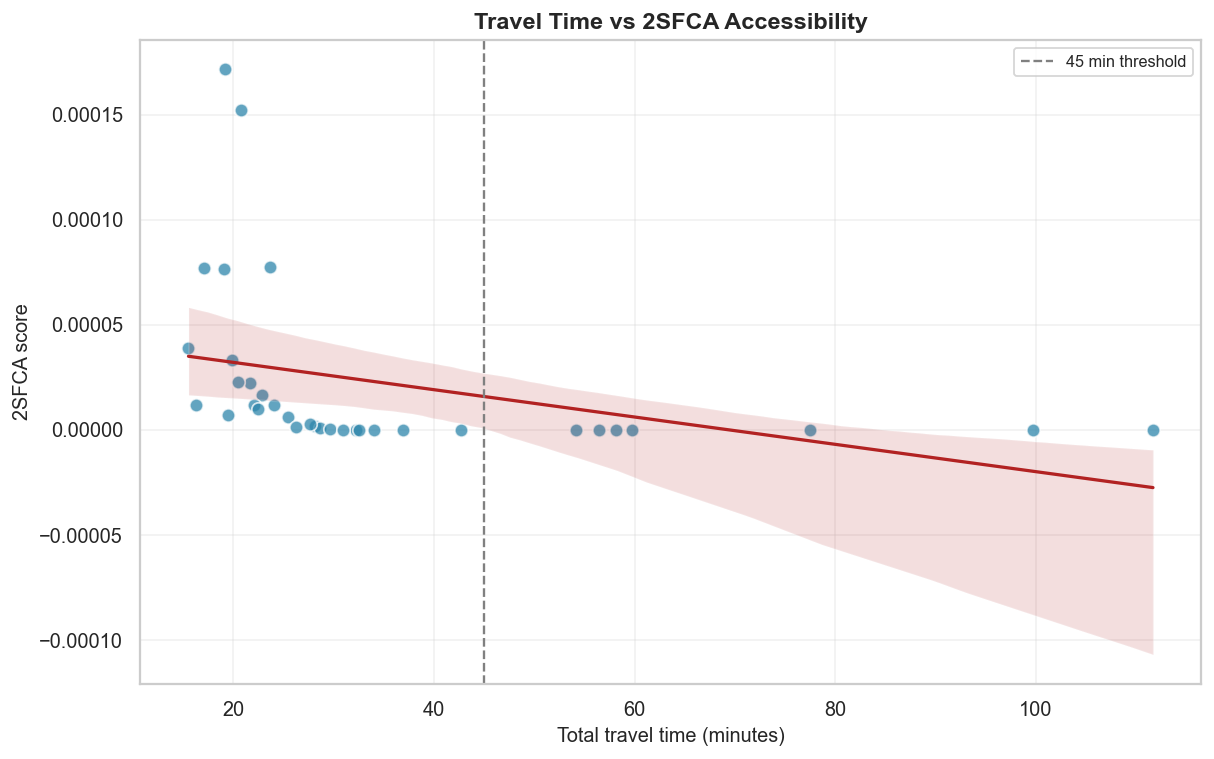

C:\Users\afafb\AppData\Local\Temp\ipykernel_10032\2891165027.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=threshold_df, x='Indicator', y='District count', palette=['#E15759', '#59A14F', '#F28E2B'], ax=ax)


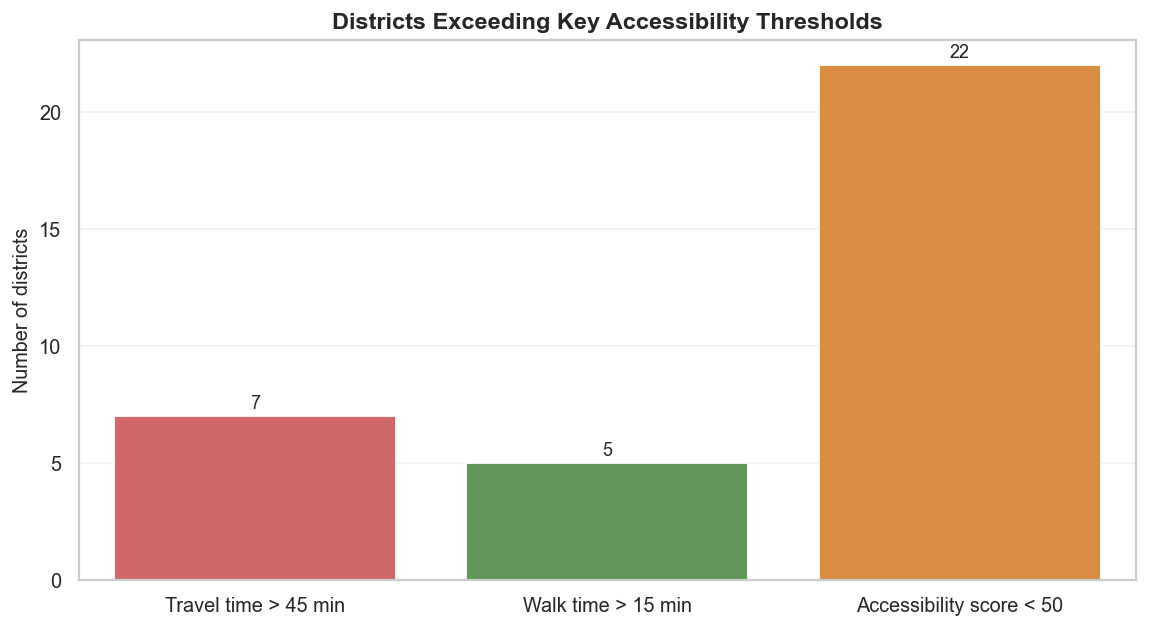

✓ Additional diagnostic plots created for interim report


In [104]:
# Additional report-oriented diagnostics with explicit thresholds

district_col = 'district' if 'district' in districts.columns else 'commune'
plot_df = districts[[district_col, 'total_travel_time_min', 'accessibility_score', 'walk_time_to_stop_min', 'score_2sfca']].copy()
plot_df = plot_df.dropna(subset=['total_travel_time_min', 'accessibility_score', 'walk_time_to_stop_min'])

# 1) Travel time histogram with 45-min threshold
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(plot_df['total_travel_time_min'], bins=16, kde=True, color='#E15759', edgecolor='white', ax=ax)
ax.axvline(45, color='black', linestyle='--', linewidth=1.8, label='45 min threshold')
ax.set_title('Distribution of District Travel Time to Nearest Healthcare')
ax.set_xlabel('Total travel time (minutes)')
ax.set_ylabel('Number of districts')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'hist_travel_time_report.png', bbox_inches='tight')
plt.show()

# 2) Accessibility score distribution (histogram + boxplot)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(plot_df['accessibility_score'], bins=14, kde=True, color='#4E79A7', edgecolor='white', ax=axes[0])
axes[0].set_title('Accessibility Score Distribution')
axes[0].set_xlabel('Accessibility score (0-100)')
axes[0].set_ylabel('Number of districts')
axes[0].grid(axis='y', alpha=0.25)

sns.boxplot(x=plot_df['accessibility_score'], color='#A0CBE8', width=0.4, ax=axes[1])
axes[1].axvline(50, color='black', linestyle='--', linewidth=1.5, label='Score 50 reference')
axes[1].set_title('Accessibility Score Boxplot')
axes[1].set_xlabel('Accessibility score (0-100)')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'dist_accessibility_score_report.png', bbox_inches='tight')
plt.show()

# 3) Walk-time distribution with 15-min threshold
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(plot_df['walk_time_to_stop_min'], bins=14, kde=True, color='#59A14F', edgecolor='white', ax=ax)
ax.axvline(15, color='black', linestyle='--', linewidth=1.8, label='15 min threshold')
ax.set_title('Walking Time to Nearest Transport Stop')
ax.set_xlabel('Walking time (minutes)')
ax.set_ylabel('Number of districts')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'hist_walk_time_to_stop_report.png', bbox_inches='tight')
plt.show()

# 4) Travel time vs 2SFCA (expected inverse pattern)
fig, ax = plt.subplots(figsize=(9.5, 6))
sns.regplot(
    data=plot_df,
    x='total_travel_time_min',
    y='score_2sfca',
    scatter_kws={'s': 55, 'alpha': 0.75, 'color': '#2E86AB', 'edgecolor': 'white'},
    line_kws={'color': '#B22222', 'linewidth': 1.8},
    ax=ax,
)
ax.axvline(45, color='gray', linestyle='--', linewidth=1.3, label='45 min threshold')
ax.set_title('Travel Time vs 2SFCA Accessibility')
ax.set_xlabel('Total travel time (minutes)')
ax.set_ylabel('2SFCA score')
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'travel_time_vs_2sfca_report.png', bbox_inches='tight')
plt.show()

# 5) District counts above thresholds
threshold_df = pd.DataFrame({
    'Indicator': ['Travel time > 45 min', 'Walk time > 15 min', 'Accessibility score < 50'],
    'District count': [
        int((plot_df['total_travel_time_min'] > 45).sum()),
        int((plot_df['walk_time_to_stop_min'] > 15).sum()),
        int((plot_df['accessibility_score'] < 50).sum()),
    ],
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=threshold_df, x='Indicator', y='District count', palette=['#E15759', '#59A14F', '#F28E2B'], ax=ax)
for i, v in enumerate(threshold_df['District count']):
    ax.text(i, v + 0.15, str(v), ha='center', va='bottom', fontsize=10)
ax.set_title('Districts Exceeding Key Accessibility Thresholds')
ax.set_xlabel('')
ax.set_ylabel('Number of districts')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / 'threshold_exceedance_counts_report.png', bbox_inches='tight')
plt.show()

print('✓ Additional diagnostic plots created for interim report')

Top districts by ranking sensitivity:


,district,total_time_slow_-20%,accessibility_slow_-20%,rank_slow_-20%,total_time_baseline,accessibility_baseline,rank_baseline,total_time_fast_+20%,accessibility_fast_+20%,rank_fast_+20%,rank_shift_slow_vs_base,rank_shift_fast_vs_base,max_abs_rank_shift
0,Bouskoura,42.658327,5.203717,27.0,42.658327,5.203717,27.0,42.658327,5.203717,27.0,0.0,0.0,0.0
25,Sbata,29.616985,34.184478,21.0,29.616985,34.184478,21.0,29.616985,34.184478,21.0,0.0,0.0,0.0
19,Mediouna,58.179046,0.000000,28.0,58.179046,0.000000,28.0,58.179046,0.000000,28.0,0.0,0.0,0.0
20,Mers Sultan,20.720720,53.953957,9.0,20.720720,53.953957,9.0,20.720720,53.953957,9.0,0.0,0.0,0.0
21,Moulay Rachid,22.491058,50.019871,12.0,22.491058,50.019871,12.0,22.491058,50.019871,12.0,0.0,0.0,0.0
22,Moulay Youssef,23.679088,47.379804,14.0,23.679088,47.379804,14.0,23.679088,47.379804,14.0,0.0,0.0,0.0
23,Nouaceur,111.654634,0.000000,28.0,111.654634,0.000000,28.0,111.654634,0.000000,28.0,0.0,0.0,0.0
24,Salmia,36.861675,18.085167,26.0,36.861675,18.085167,26.0,36.861675,18.085167,26.0,0.0,0.0,0.0
26,Sidi Belyout,26.233856,41.702543,17.0,26.233856,41.702543,17.0,26.233856,41.702543,17.0,0.0,0.0,0.0
1,Bouskoura,59.765550,0.000000,28.0,59.765550,0.000000,28.0,59.765550,0.000000,28.0,0.0,0.0,0.0


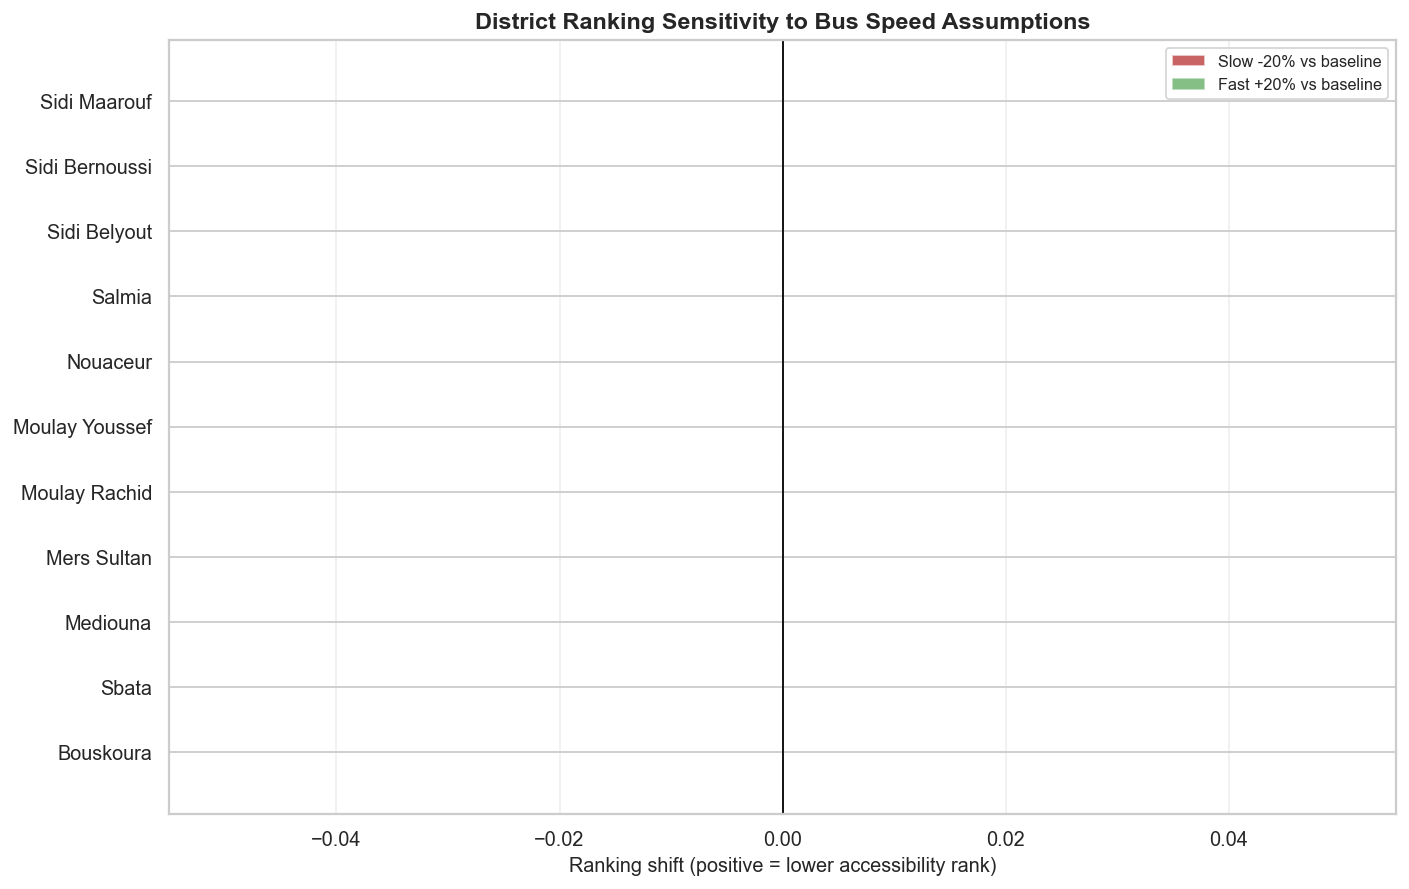

In [105]:
district_col = 'district' if 'district' in districts_with_population.columns else 'commune'
districts_with_population["walk_time_to_stop_min"] = districts['walk_time_to_stop_min'].copy()

def compute_total_times_for_speed(speed_m_min):
    scenario_graph = G.copy()
    for u, v, data in scenario_graph.edges(data=True):
        if data.get('mode') == 'transit' and data.get('distance') is not None:
            scenario_graph[u][v]['weight'] = data['distance'] / speed_m_min

    scenario_times, _ = calculate_total_travel_time(
        origin_points,
        stops,
        health_nodes,
        scenario_graph,
        districts_with_population['walk_time_to_stop_min'].values,
        stop_indices,
    )
    return scenario_times


speed_scenarios = {
    'slow_-20%': BUS_SPEED_M_MIN * 0.8,
    'baseline': BUS_SPEED_M_MIN,
    'fast_+20%': BUS_SPEED_M_MIN * 1.2,
}

sensitivity_df = districts_with_population[[district_col]].copy()
for label, scenario_speed in speed_scenarios.items():
    tt = compute_total_times_for_speed(scenario_speed)
    sensitivity_df[f'total_time_{label}'] = tt
    sensitivity_df[f'accessibility_{label}'] = [calculate_accessibility_score(x) for x in tt]
    sensitivity_df[f'rank_{label}'] = sensitivity_df[f'accessibility_{label}'].rank(ascending=False, method='min')

sensitivity_df['rank_shift_slow_vs_base'] = sensitivity_df['rank_slow_-20%'] - sensitivity_df['rank_baseline']
sensitivity_df['rank_shift_fast_vs_base'] = sensitivity_df['rank_fast_+20%'] - sensitivity_df['rank_baseline']
sensitivity_df['max_abs_rank_shift'] = sensitivity_df[['rank_shift_slow_vs_base', 'rank_shift_fast_vs_base']].abs().max(axis=1)

print('Top districts by ranking sensitivity:')
display(sensitivity_df.sort_values('max_abs_rank_shift', ascending=False).head(10))

plot_df = sensitivity_df.sort_values('max_abs_rank_shift', ascending=False).head(12).copy()
plot_df = plot_df.sort_values('max_abs_rank_shift')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df[district_col], plot_df['rank_shift_slow_vs_base'], color='firebrick', alpha=0.7, label='Slow -20% vs baseline')
ax.barh(plot_df[district_col], plot_df['rank_shift_fast_vs_base'], color='forestgreen', alpha=0.55, label='Fast +20% vs baseline')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Ranking shift (positive = lower accessibility rank)')
ax.set_title('District Ranking Sensitivity to Bus Speed Assumptions')
ax.grid(True, axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 9.3 Socioeconomic Vulnerability Overlay (Proxy)

If district-level socioeconomic deprivation indicators are unavailable, population density is used here as a vulnerability proxy to identify doubly disadvantaged districts (low accessibility + high vulnerability).

Using population density as vulnerability proxy (socioeconomic field not found).


KeyError: 'pop_density'

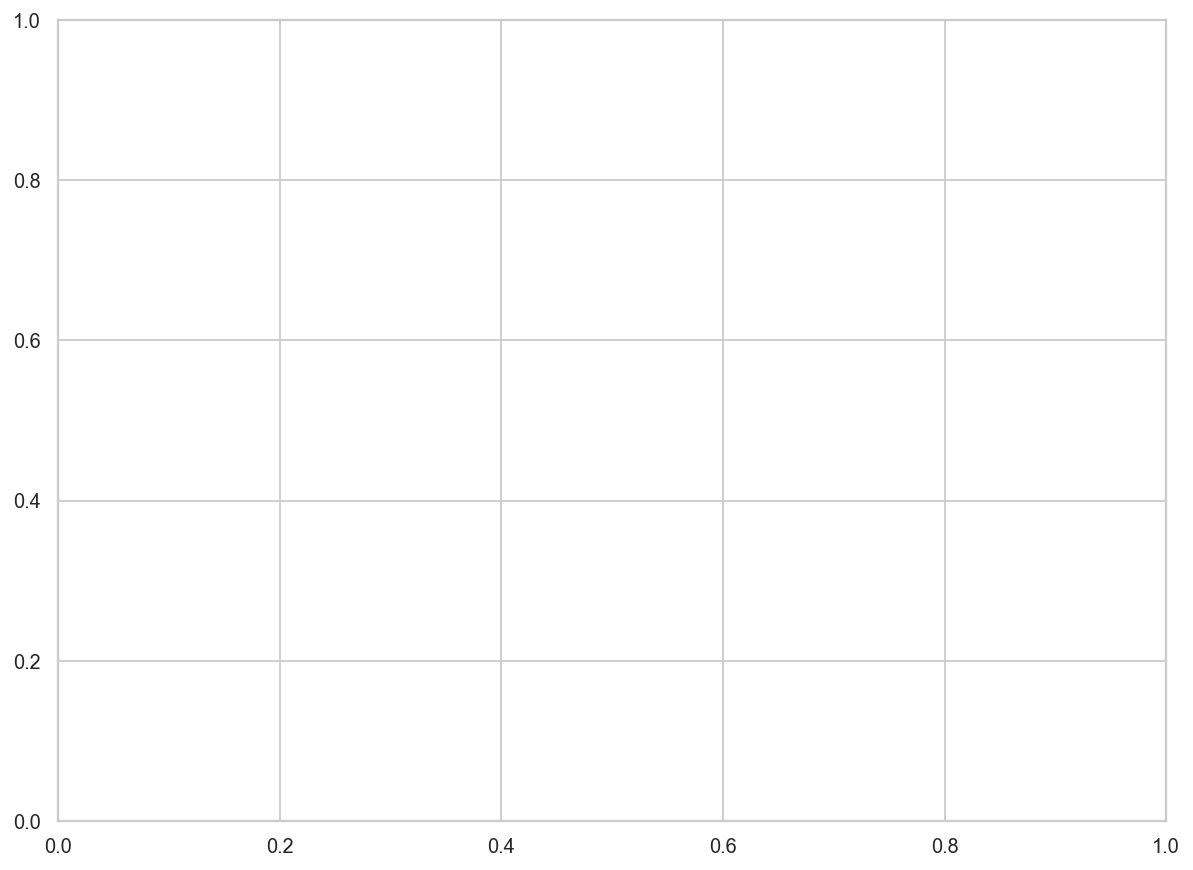

In [106]:
# Build a vulnerability proxy with available fields
if 'pop_density' not in districts.columns and {'population', 'area_km2'}.issubset(districts.columns):
    districts['pop_density'] = districts['population'] / districts['area_km2'].replace(0, np.nan)

vulnerability_col = None
for candidate in ['unemployment_rate', 'deprivation_index', 'informal_housing_share', 'education_deficit_rate']:
    if candidate in districts.columns:
        vulnerability_col = candidate
        break

if vulnerability_col is None:
    vulnerability_col = 'pop_density'
    print('Using population density as vulnerability proxy (socioeconomic field not found).')

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(
    districts[vulnerability_col],
    districts['accessibility_score'],
    s=np.clip(districts['population'] / 5000, 30, 350) if 'population' in districts.columns else 80,
    c=districts['accessibility_score'],
    cmap='RdYlGn',
    alpha=0.75,
    edgecolor='black',
)

x_thr = districts[vulnerability_col].median()
y_thr = districts['accessibility_score'].median()
ax.axvline(x_thr, linestyle='--', color='gray', linewidth=1.2, label='Median vulnerability')
ax.axhline(y_thr, linestyle='--', color='black', linewidth=1.2, label='Median accessibility')

for _, row in districts.iterrows():
    ax.annotate(str(row[district_col]), (row[vulnerability_col], row['accessibility_score']), fontsize=7)

ax.set_xlabel(vulnerability_col.replace('_', ' ').title())
ax.set_ylabel('Accessibility Score')
ax.set_title('Accessibility vs Socioeconomic Vulnerability Proxy')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary Statistics and Rankings

In [107]:
# Create summary table
district_col = 'district' if 'district' in districts.columns else 'commune'

summary_cols = [
    district_col, 'population', 'area_km2', 'pop_density',
    'walk_time_to_stop_min', 'total_travel_time_min',
    'accessibility_score', 'accessibility_category', 'score_2sfca'
]
summary_cols = [col for col in summary_cols if col in districts.columns]

summary_df = districts[summary_cols].copy().sort_values('accessibility_score', ascending=False)

print('=' * 80)
print('DISTRICT ACCESSIBILITY RANKINGS')
print('=' * 80)
print('\nTop 10 Most Accessible Districts:')
print('=' * 80)
display(summary_df.head(10))

print('\n' + '=' * 80)
print('Bottom 10 Least Accessible Districts:')
print('=' * 80)
display(summary_df.tail(10))


DISTRICT ACCESSIBILITY RANKINGS

Top 10 Most Accessible Districts:


,district,area_km2,walk_time_to_stop_min,total_travel_time_min,accessibility_score,accessibility_category,score_2sfca
27,Sidi Bernoussi,14.300270,3.212815,15.524034,65.502147,Good,0.000039
15,Hay Hassani,15.340639,3.055908,16.307650,63.760777,Good,0.000012
14,El Maarif,12.748229,2.856039,17.047749,62.116113,Good,0.000077
13,Bou Chentouf,2.292228,2.521556,19.059005,57.646656,Good,0.000076
18,Machouar Casablanca,0.517805,1.186342,19.212561,57.305421,Good,0.000172
30,Sidi Othmane,7.143545,3.224649,19.497516,56.672187,Good,0.000007
9,Al Idrissia,1.792749,2.636949,19.870760,55.842755,Good,0.000033
16,Hay Mohammadi,4.522645,3.359632,20.449837,54.555917,Good,0.000023
20,Mers Sultan,2.029221,2.015881,20.720720,53.953957,Good,0.000152
7,Ain Sebaa,22.495756,2.993550,21.635779,51.920491,Good,0.000022



Bottom 10 Least Accessible Districts:


,district,area_km2,walk_time_to_stop_min,total_travel_time_min,accessibility_score,accessibility_category,score_2sfca
3,Mediouna,20.105620,5.175821,34.050218,24.332849,Poor,0.0
24,Salmia,4.775528,7.366668,36.861675,18.085167,Poor,0.0
0,Bouskoura,114.642679,4.277528,42.658327,5.203717,Poor,0.0
23,Nouaceur,48.033560,36.134504,111.654634,0.000000,Poor,0.0
28,Sidi Maarouf,24.257617,25.173986,56.453029,0.000000,Poor,0.0
19,Mediouna,3.435040,2.595799,58.179046,0.000000,Poor,0.0
1,Bouskoura,150.362928,34.567619,59.765550,0.000000,Poor,0.0
2,Mediouna,93.812338,2.948932,54.171452,0.000000,Poor,0.0
32,Tit Mellil,68.398609,50.471149,77.458887,0.000000,Poor,0.0
33,Tit Mellil,97.580445,64.209571,99.743913,0.000000,Poor,0.0


In [108]:
# Overall statistics
print('=' * 80)
print('OVERALL ACCESSIBILITY STATISTICS')
print('=' * 80)

print('\nStudy Area:')
print(f'  Total districts: {len(districts)}')
print(f'  Total area: {districts["area_km2"].sum():.2f} km²')
if 'population' in districts.columns:
    print(f'  Total population: {districts["population"].sum():,.0f}')
    print(f'  Average population density: {districts["pop_density"].mean():.1f} per km²')

print('\nHealthcare Infrastructure:')
print(f'  Healthcare facilities: {len(hospitals)}')
print(f'  Transport stops: {len(stops)}')

print('\nAccessibility Metrics:')
print(f'  Average travel time: {districts["total_travel_time_min"].mean():.1f} minutes')
print(f'  Median travel time: {districts["total_travel_time_min"].median():.1f} minutes')
print(f'  Average accessibility score: {districts["accessibility_score"].mean():.1f}')
print(f'  Average 2SFCA score: {districts["score_2sfca"].mean():.6f}')
print(f'  Districts with excellent access (score ≥75): {(districts["accessibility_score"] >= 75).sum()}')
print(f'  Districts with poor access (score <50): {(districts["accessibility_score"] < 50).sum()}')

if 'population' in districts.columns:
    print('\nPopulation-Weighted Metrics:')
    print(f'  Weighted avg travel time: {weighted_travel_time:.1f} minutes')
    print(f'  Population with poor access: {pop_poor_access:,.0f} ({100 * pop_poor_access / total_pop:.1f}%)')
    print(f'  Weighted Gini (accessibility score): {pop_weighted_gini:.3f}')


OVERALL ACCESSIBILITY STATISTICS

Study Area:
  Total districts: 34
  Total area: 837.37 km²

Healthcare Infrastructure:
  Healthcare facilities: 84
  Transport stops: 1463

Accessibility Metrics:
  Average travel time: 35.2 minutes
  Median travel time: 26.9 minutes
  Average accessibility score: 35.0
  Average 2SFCA score: 0.000022
  Districts with excellent access (score ≥75): 0
  Districts with poor access (score <50): 22


In [109]:
# Travel time stats
print(districts['total_travel_time_min'].describe())

# % underserved (>45 min)
print((districts['total_travel_time_min'] > 45).mean() * 100)

# Accessibility score stats
print(districts['accessibility_score'].describe())

# % low accessibility (<20)
print((districts['accessibility_score'] < 20).mean() * 100)

# 2SFCA stats
print(districts['2sfca_score'].describe())

# % near zero (very low access)
print((districts['2sfca_score'] < districts['2sfca_score'].quantile(0.2)).mean() * 100)

count     34.000000
mean      35.200972
std       23.104892
min       15.524034
25%       20.949484
50%       26.916406
75%       36.158811
max      111.654634
Name: total_travel_time_min, dtype: float64
20.588235294117645
count    34.000000
mean     35.006108
std      22.369614
min       0.000000
25%      19.647087
50%      40.185764
75%      53.445590
max      65.502147
Name: accessibility_score, dtype: float64
26.47058823529412
count    34.000000
mean      0.000022
std       0.000042
min       0.000000
25%       0.000000
50%       0.000002
75%       0.000021
max       0.000172
Name: 2sfca_score, dtype: float64
0.0


## 11. Final Insights and Recommendations

### Key Findings
- Healthcare and transport services are not evenly distributed across Casablanca.
- Accessibility varies significantly by district, with a visible center-periphery gradient.
- Population-weighted metrics indicate that accessibility deficits can affect substantial resident groups.

### Likely Underserved Areas
Districts combining high travel times, lower accessibility scores, and large populations should be treated as priority underserved zones.
Where clustering outputs indicate sparse service patterns, those zones warrant targeted validation and intervention.

### Practical Planning Recommendations
1. Prioritize new primary-care facilities in high-population districts with poor accessibility scores.
2. Improve feeder transit and stop density around low-access districts and peripheral communes.
3. Increase multimodal integration (bus-tram connections) in districts with limited route diversity.
4. Use periodic re-evaluation with updated population and service data to monitor equity improvements.

### Conclusion
The evidence indicates that healthcare accessibility in Casablanca is spatially unequal.
A planning strategy that jointly optimizes facility placement and transport connectivity is essential to reduce underserved conditions and improve urban health equity.